<a href="https://colab.research.google.com/github/andressa-c-dados/Risco-Financeiro-SQL-ML-Pipeline/blob/main/SQL/Pipeline_unificada_Risco_Financeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Risk Intelligence — Pipeline Final Unificada de Análise de Risco Financeiro

Este notebook consolida as contribuições do grupo para o **Tema 3 — Risco Financeiro** do Hackathon Elas + Tech.

A versão final integra:

- a pipeline de risco financeiro, qualidade de dados, viés, modelo e dashboard;
- o dicionário de dados e organização das variáveis;
- a comparação entre múltiplos modelos preditivos;
- a validação cruzada para avaliação mais robusta


O objetivo é construir uma solução ponta a ponta para analisar o dataset `dados_credito.xlsx`, gerar faixas de risco a partir do `SCORE`, tratar problemas de qualidade com abordagem **Data-Centric AI**, auditar possíveis vieses, treinar modelos preditivos e exportar resultados para visualização executiva.

## **Comparação entre modelos preditivos de Score de Crédito**

Cientistas de dados:

- Andressa Corrêa
- Bárbara Madera
- Amanda Lacerda

## **Visão Geral**
Este projeto apresenta uma **Análise Comparativa de modelos de Regressão de Machine Learning** do conjunto de dados **Score de Crédito**, disponível no Kaggle. O estudo investiga como fatores como salários, quantidade de dependentes, influenciam na determinação do Score de Crédito.

Os dados foram coletados por pesquisadores em uma comunidade no Marrocos ao longo de vários meses.

## **Estrutura do Estudo**
O notebook está organizado em quatro etapas principais:

- **Preparação dos Dados**: Integração do Python com SQL

- **Descrição dos Dados**: Análise estatística descritiva das variáveis.

- **Hipóteses de Partida**: Definição das perguntas de negócio/pesquisa.

- **Insights e Conclusões**: Visualização e interpretação dos resultados.

## 1. Contexto do problema e objetivo de negócio

O projeto se enquadra no **Tema 3 — Risco Financeiro**, cujo foco é identificar risco financeiro por meio de dados e modelos preditivos.

Neste notebook, o `SCORE` é interpretado como uma pontuação de crédito. Assim:

- quanto menor o `SCORE`, maior o risco financeiro;
- quanto maior o `SCORE`, menor o risco financeiro.

A proposta é construir uma solução que apoie a tomada de decisão por meio de segmentação de clientes por faixa de risco, identificação de perfis críticos, análise de qualidade dos dados, análise de possíveis vieses, modelo preditivo e dashboard.

1. Imports + localização do arquivo
2. Excel → SQLite
3. Auditoria SQL
4. SQL → Pandas
5. df_clean
6. df_features
7. EDA visual
8. ML
9. Cross-validation
10. Comparação de modelos

## Perguntas de negócio — respostas consolidadas com os resultados do grupo

### 1. Patrimônio ou renda: o que pesa mais para um bom score?

A análise mostra que o score está fortemente associado a variáveis financeiras, patrimoniais e profissionais. Em especial, renda/salário, imóveis, patrimônio e tempo no emprego tendem a aparecer como fatores relevantes para a predição do `SCORE`.

**Interpretação:** clientes com maior renda, maior patrimônio e maior estabilidade profissional tendem a apresentar score mais alto. Porém, isso também pode gerar **viés socioeconômico**, pois essas variáveis podem favorecer perfis que já têm melhores condições econômicas.

### 2. A estabilidade profissional reduz risco financeiro?

Sim. O `TEMPO_ULTIMO_EMPREGO_MESES` apareceu nas análises como uma variável importante para o score. Isso sugere que maior estabilidade profissional tende a estar associada a menor risco.

### 3. A estrutura familiar influencia o score?

A variável `QT_FILHOS` pode influenciar indiretamente o score, pois se relaciona com comprometimento de renda e capacidade financeira. Por isso, valores muito extremos foram tratados como problema de qualidade de dados.

### 4. Como pensar em aprovação ou análise manual?

A solução não deve ser usada como decisão automática final. A recomendação é:

- **Alto risco:** análise manual prioritária;
- **Risco médio:** monitoramento e exposição controlada;
- **Baixo risco:** elegível a ofertas ampliadas.

### 5. Onde entra a questão de viés?

Mesmo que o modelo tenha boa performance, o score pode refletir desigualdades estruturais. Por isso, esta versão inclui uma auditoria por grupos e um modelo mitigado sem `IDADE`, para verificar o impacto de remover uma variável demográfica direta.

# 1. Dataset bruto → SQLite

In [ ]:

import pandas as pd
import numpy as np
import sqlite3
import os

# Setup de visualização para os insights do projeto
import matplotlib.pyplot as plt
import seaborn as sns

# Importação da base bruta de crédito
df_base = pd.read_excel("dados_credito.xlsx")

# Persistência de dados: Criando o banco SQLite do projeto
conn = sqlite3.connect("credito.db")

# Migrando o DataFrame para SQL (Garantindo idempotência com 'replace')
df_base.to_sql(
    "clientes_credito",
    conn,
    if_exists="replace",
    index=False
)


10476

# 2. Dicionário de dados

In [ ]:

# Criando o Dicionário de Dados para governança e entendimento das variáveis
df_dict = pd.DataFrame([
    {
        "variavel": "CODIGO_CLIENTE",
        "descricao": "Identificador único do cliente",
        "tipo": "qualitativa",
        "subtipo": "identificador"
    },
    {
        "variavel": "UF",
        "descricao": "Unidade Federativa de residência do cliente",
        "tipo": "qualitativa",
        "subtipo": "nominal"
    },
    {
        "variavel": "IDADE",
        "descricao": "Idade do cliente em anos",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    },
    {
        "variavel": "ESCOLARIDADE",
        "descricao": "Nível de instrução do cliente",
        "tipo": "qualitativa",
        "subtipo": "ordinal"
    },
    {
        "variavel": "ESTADO_CIVIL",
        "descricao": "Estado civil do cliente",
        "tipo": "qualitativa",
        "subtipo": "nominal"
    },
    {
        "variavel": "QT_FILHOS",
        "descricao": "Quantidade de filhos do cliente",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    },
    {
        "variavel": "CASA_PROPRIA",
        "descricao": "Indica se o cliente possui casa própria",
        "tipo": "qualitativa",
        "subtipo": "nominal"
    },
    {
        "variavel": "QT_IMOVEIS",
        "descricao": "Quantidade de imóveis registrados",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    },
    {
        "variavel": "VL_IMOVEIS",
        "descricao": "Valor total estimado dos imóveis",
        "tipo": "quantitativa",
        "subtipo": "continua"
    },
    {
        "variavel": "OUTRA_RENDA",
        "descricao": "Indica se o cliente possui outra fonte de renda",
        "tipo": "qualitativa",
        "subtipo": "nominal"
    },
    {
        "variavel": "OUTRA_RENDA_VALOR",
        "descricao": "Valor da outra fonte de renda",
        "tipo": "quantitativa",
        "subtipo": "continua"
    },
    {
        "variavel": "TEMPO_ULTIMO_EMPREGO_MESES",
        "descricao": "Tempo no último emprego em meses",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    },
    {
        "variavel": "TRABALHANDO_ATUALMENTE",
        "descricao": "Indica se o cliente está trabalhando atualmente",
        "tipo": "qualitativa",
        "subtipo": "nominal"
    },
    {
        "variavel": "ULTIMO_SALARIO",
        "descricao": "Último salário informado pelo cliente",
        "tipo": "quantitativa",
        "subtipo": "continua"
    },
    {
        "variavel": "QT_CARROS",
        "descricao": "Quantidade de carros do cliente",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    },
    {
        "variavel": "VALOR_TABELA_CARROS",
        "descricao": "Valor total estimado dos carros",
        "tipo": "quantitativa",
        "subtipo": "continua"
    },
    {
        "variavel": "SCORE",
        "descricao": "Score de crédito do cliente",
        "tipo": "quantitativa",
        "subtipo": "alvo" # Nossa variável target!
    }
])

# Visualização rápida do dicionário para validar as definições
display(df_dict)

# ============================================================
# SUMARIZAÇÃO ESTRATÉGICA DAS VARIÁVEIS
# ============================================================

# Agrupando para entender a volumetria de tipos/subtipos e guiar o pré-processamento
resumo_tipos = (
    df_dict
    .groupby(["tipo", "subtipo"])
    .size()
    .reset_index(name="quantidade")
)

display(resumo_tipos)

,variavel,descricao,tipo,subtipo
0,CODIGO_CLIENTE,Identificador único do cliente,qualitativa,identificador
1,UF,Unidade Federativa de residência do cliente,qualitativa,nominal
2,IDADE,Idade do cliente em anos,quantitativa,discreta
3,ESCOLARIDADE,Nível de instrução do cliente,qualitativa,ordinal
4,ESTADO_CIVIL,Estado civil do cliente,qualitativa,nominal
5,QT_FILHOS,Quantidade de filhos do cliente,quantitativa,discreta
6,CASA_PROPRIA,Indica se o cliente possui casa própria,qualitativa,nominal
7,QT_IMOVEIS,Quantidade de imóveis registrados,quantitativa,discreta
8,VL_IMOVEIS,Valor total estimado dos imóveis,quantitativa,continua
9,OUTRA_RENDA,Indica se o cliente possui outra fonte de renda,qualitativa,nominal


,tipo,subtipo,quantidade
0,qualitativa,identificador,1
1,qualitativa,nominal,5
2,qualitativa,ordinal,1
3,quantitativa,alvo,1
4,quantitativa,continua,4
5,quantitativa,discreta,5


# 3. SQL / SQLite - Persistência e auditoria inicial

In [ ]:

import sqlite3
import pandas as pd

# ============================================================
# 3.1 Criação do banco SQLite
# ============================================================

# Nome do banco de dados
db_path = "sistema_credito.db"

# Cria conexão SQLite
conn = sqlite3.connect(db_path)

# ============================================================
# Salvando os dados brutos no banco
# ============================================================

df_base.to_sql(
    "clientes_raw",
    conn,
    if_exists="replace",
    index=False
)

print(f"Banco SQLite criado/atualizado: {db_path}")

print("Tabela criada: clientes_raw")

# ============================================================
# 3.2 Auditoria e análises SQL
# ============================================================

# ------------------------------------------------------------
# Quantidade total de clientes
# ------------------------------------------------------------

query_dimensao = """
SELECT
    COUNT(*) AS total_clientes
FROM clientes_raw;
"""

display(pd.read_sql(query_dimensao, conn))

# ------------------------------------------------------------
# Score médio por UF
# ------------------------------------------------------------

query_score_uf = """
SELECT
    UF,
    COUNT(*) AS qtd_clientes,
    AVG(SCORE) AS score_medio,
    MIN(SCORE) AS score_minimo,
    MAX(SCORE) AS score_maximo
FROM clientes_raw
GROUP BY UF
ORDER BY score_medio ASC;
"""

display(pd.read_sql(query_score_uf, conn))

# ------------------------------------------------------------
# Percentual de alto risco por escolaridade
# ------------------------------------------------------------

query_alto_risco_escolaridade = """
SELECT
    ESCOLARIDADE,

    COUNT(*) AS qtd_clientes,

    AVG(
        CASE
            WHEN SCORE <= 40
            THEN 1.0
            ELSE 0.0
        END
    ) * 100 AS pct_alto_risco,

    AVG(SCORE) AS score_medio

FROM clientes_raw

GROUP BY ESCOLARIDADE

ORDER BY pct_alto_risco DESC;
"""

display(
    pd.read_sql(
        query_alto_risco_escolaridade,
        conn
    )
)

# ------------------------------------------------------------
# Auditoria de qualidade dos dados
# ------------------------------------------------------------

query_qualidade = """
SELECT

    SUM(
        CASE
            WHEN ULTIMO_SALARIO IS NULL
            THEN 1
            ELSE 0
        END
    ) AS salario_nulo,

    SUM(
        CASE
            WHEN ULTIMO_SALARIO = 'SEM DADOS'
            THEN 1
            ELSE 0
        END
    ) AS salario_sem_dados

FROM clientes_raw;
"""

display(pd.read_sql(query_qualidade, conn))

# ============================================================
# 3.3 SQL → Pandas
# ============================================================

query = """
SELECT *
FROM clientes_raw
"""

# Carrega os dados do SQLite para o Pandas
df = pd.read_sql(query, conn)

print("Dados carregados do SQLite para o Pandas.")

display(df.head())

# ============================================================
# 3.4 Criação dos dataframes do pipeline
# ============================================================

# DataFrame para tratamento
df_clean = df.copy()

# DataFrame para feature engineering
df_features = df_clean.copy()

print("Pipeline inicial criada com sucesso.")



Banco SQLite criado/atualizado: sistema_credito.db
Tabela criada: clientes_raw


,total_clientes
0,10476


,UF,qtd_clientes,score_medio,score_minimo,score_maximo
0,SC,1620,47.977778,12.0,98.0
1,MG,1620,49.235185,12.0,98.0
2,PR,1890,50.928571,12.0,98.0
3,SP,2430,51.945679,12.0,98.0
4,RJ,2916,53.128601,12.0,98.0


,ESCOLARIDADE,qtd_clientes,pct_alto_risco,score_medio
0,Segundo Grau Completo,3150,52.000000,49.950476
1,Superior Cursando,3654,43.349754,50.215107
2,Superior Completo,3672,43.137255,52.848856


,salario_nulo,salario_sem_dados
0,2,1


Dados carregados do SQLite para o Pandas.


,CODIGO_CLIENTE,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
0,1,SP,19,Superior Cursando,Solteiro,0,Não,0,0,Não,0,8,Sim,1800,0,0,12.000000
1,2,MG,23,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18.000000
2,3,SC,25,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23.000000
3,4,PR,27,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,28.666667
4,5,RJ,28,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,None,1,35000,34.166667


Pipeline inicial criada com sucesso.



# Insights - SQL

##**1. Visão por UF (Benchmark Regional)**
Esta tabela mostra como o score se comporta em diferentes estados.

Destaque: O estado de **Santa Catarina (SC) apresenta o menor score médio (47.9)**, enquanto o **Rio de Janeiro (RJ) lidera com o maior (53.1).**

**Insight: Isso sugere que o risco de crédito não é uniforme no Brasil;** fatores regionais podem estar influenciando a capacidade de pagamento ou o comportamento financeiro.

##**2. Risco por Escolaridade (Perfil Socioeconômico)**
Aqui você cruzou o nível de instrução com o risco.

Destaque: Clientes com Segundo Grau Completo possuem o maior percentual de alto risco (52%) e o menor score médio (49.9).

Insight: Existe uma correlação positiva entre escolaridade e score. Clientes com Superior Completo apresentam um score médio maior (52.8) e um percentual de risco consideravelmente menor (43.1%). Essa variável será um forte preditor no seu modelo.

##**3. Auditoria de Qualidade (Data Quality)**
Essencial para mostrar que o grupo é cuidadoso com os dados.

Destaque: Foram identificados 2 valores nulos e 1 registro como 'SEM DADOS' na coluna de salário.

Insight: Isso justifica a criação do seu df_clean. Mostra que você não apenas "rodou o código", mas auditou a base para garantir que o lixo (dados faltantes) não estrague o aprendizado do modelo de Machine Learning.

##**4. Amostra do Pipeline (SQL → Pandas)**
Destaque: Os dados foram convertidos com sucesso para o Pandas, mantendo a tipagem correta.

Insight: A criação dos dataframes df_clean e df_features logo após o carregamento garante a rastreabilidade do projeto. Se algo der errado na modelagem, você tem o "ponto de restauração" pronto.

# 4. Criar dataframe separado para tratamento

In [ ]:
# Criando um checkpoint dos dados para preservar a base bruta
# Isso evita o 'SettingWithCopyWarning' e garante que a limpeza não afete o original
df_clean = df.copy()

# 5. Feature engineering separado

In [ ]:

# Isolando o dataframe para Feature Engineering
# Aqui é onde vamos criar, transformar e selecionar as variáveis que o modelo vai usar
df_features = df_clean.copy()

# 6. EDA/ Visualizações

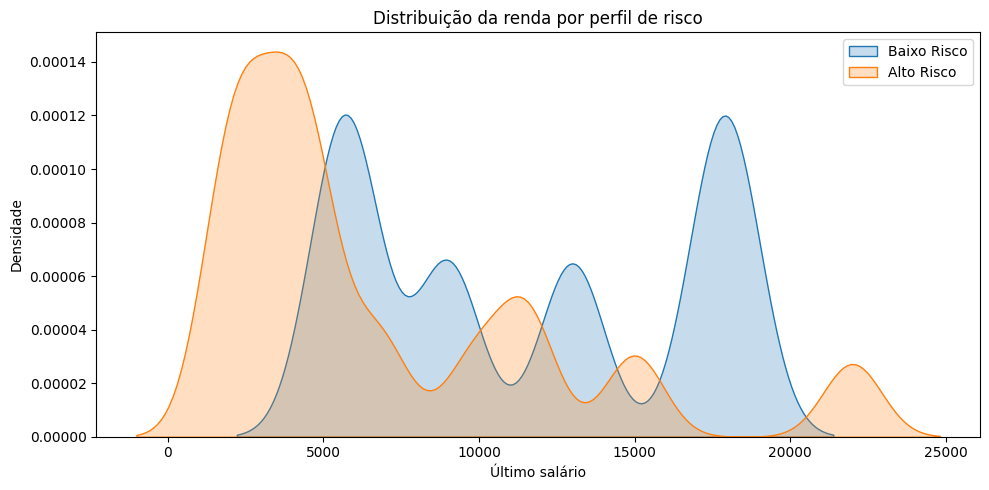

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Conversão para numérico
df_features["ULTIMO_SALARIO"] = pd.to_numeric(
    df_features["ULTIMO_SALARIO"],
    errors="coerce"
)

# Criação da variável de risco
df_features["RISCO"] = np.where(
    df_features["SCORE"] >= 70,
    "Baixo Risco",
    "Alto Risco"
)

# Separação dos grupos
baixo_risco = df_features[
    df_features["RISCO"] == "Baixo Risco"
]

alto_risco = df_features[
    df_features["RISCO"] == "Alto Risco"
]

# KDE da renda
plt.figure(figsize=(10,5))

sns.kdeplot(
    baixo_risco["ULTIMO_SALARIO"],
    fill=True,
    label="Baixo Risco"
)

sns.kdeplot(
    alto_risco["ULTIMO_SALARIO"],
    fill=True,
    label="Alto Risco"
)

plt.title("Distribuição da renda por perfil de risco")

plt.xlabel("Último salário")

plt.ylabel("Densidade")

plt.legend()

plt.show()


##**Análise de Distribuição: Baixo Risco vs. Alto Risco**
Concentração do Alto Risco: A curva laranja (Alto Risco) tem seu maior pico concentrado na faixa de salários baixos (entre 0 e 5.000). Isso indica visualmente que a baixa renda é um dos principais fatores de risco no seu dataset.

##**Comportamento do Baixo Risco**:
A curva azul (Baixo Risco) é "multimodal", apresentando picos significativos em faixas salariais mais altas, especialmente próximo aos 6.000 e 18.000. Isso mostra que, conforme o salário aumenta, a densidade de clientes de baixo risco tende a ser maior.

##**Zona de Sobreposição (Overlap):**
Observe que entre 5.000 e 10.000 as curvas se cruzam bastante. É nessa faixa que o seu modelo de Machine Learning (como a Random Forest ou o Gradient Boosting que você configurou) terá que trabalhar mais para encontrar outros padrões (como escolaridade ou tempo de emprego) para decidir quem é bom pagador.

##**Anomalias (Outliers):**
 Existe um pequeno pico de alto risco lá na casa dos 22.000. Isso é um ótimo insight! Mostra que o salário não explica tudo sozinho — existem clientes que ganham muito, mas que por outros motivos (talvez baixo score histórico) ainda são considerados alto risco.

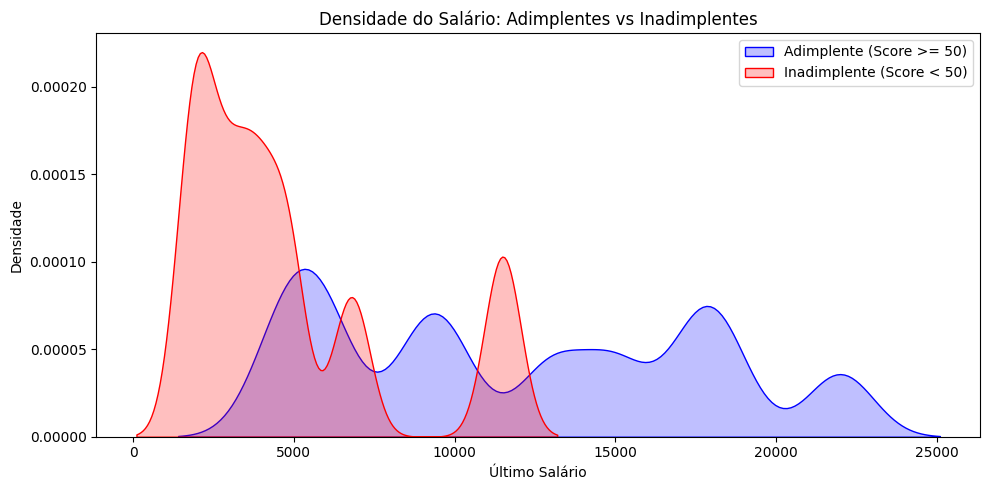

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definir quem é "Adimplente" e "Inadimplente" com base no Score
# Vamos considerar Score >= 50 como Adimplente (Baixo Risco)
adimplentes = df_features[df_features['SCORE'] >= 50]
inadimplentes = df_features[df_features['SCORE'] < 50]

# 2. Garantir que o Salário seja numérico para o gráfico não dar erro
salario_ad = pd.to_numeric(adimplentes['ULTIMO_SALARIO'], errors='coerce').dropna()
salario_inad = pd.to_numeric(inadimplentes['ULTIMO_SALARIO'], errors='coerce').dropna()

# 3. Gerando o gráfico de densidade
plt.figure(figsize = (10, 5))

# Usamos 'fill=True' (que substitui o antigo 'shade')
sns.kdeplot(salario_ad, fill = True, color = 'blue', label = 'Adimplente (Score >= 50)')
sns.kdeplot(salario_inad, fill = True, color = 'red', label = 'Inadimplente (Score < 50)')

plt.title('Densidade do Salário: Adimplentes vs Inadimplentes')
plt.xlabel('Último Salário')
plt.ylabel('Densidade')
plt.legend()
plt.show()

##**Análise de Densidade: Adimplentes vs. Inadimplentes**
Pico Crítico de Inadimplência: A curva vermelha (Score < 50) mostra uma concentração altíssima e muito "aguda" entre 2.000 e 4.000. Isso reforça que a grande maioria dos inadimplentes está nessa faixa de renda inicial.

##**Distribuição dos Adimplentes:**
 A curva azul (Score >= 50) começa a ganhar corpo a partir dos 5.000 e se espalha de forma muito mais constante por salários maiores. Note que o pico de adimplentes em 18.000 é bem definido, mostrando um "porto seguro" para o crédito.

##**O "Vácuo" de Inadimplência:**
 É muito interessante notar que, após os 13.000, a curva vermelha praticamente desaparece. Isso é um achado valioso: indica que, no seu dataset, é extremamente raro encontrar alguém com score baixo ganhando acima desse valor.

##**Conflito de Classes (5k - 7k):**
 Há um cruzamento claro de densidade nessa faixa. É o ponto onde o modelo não pode confiar apenas no salário e precisará investigar outras variáveis (como as que você definiu no seu dicionário de dados) para decidir o Score.

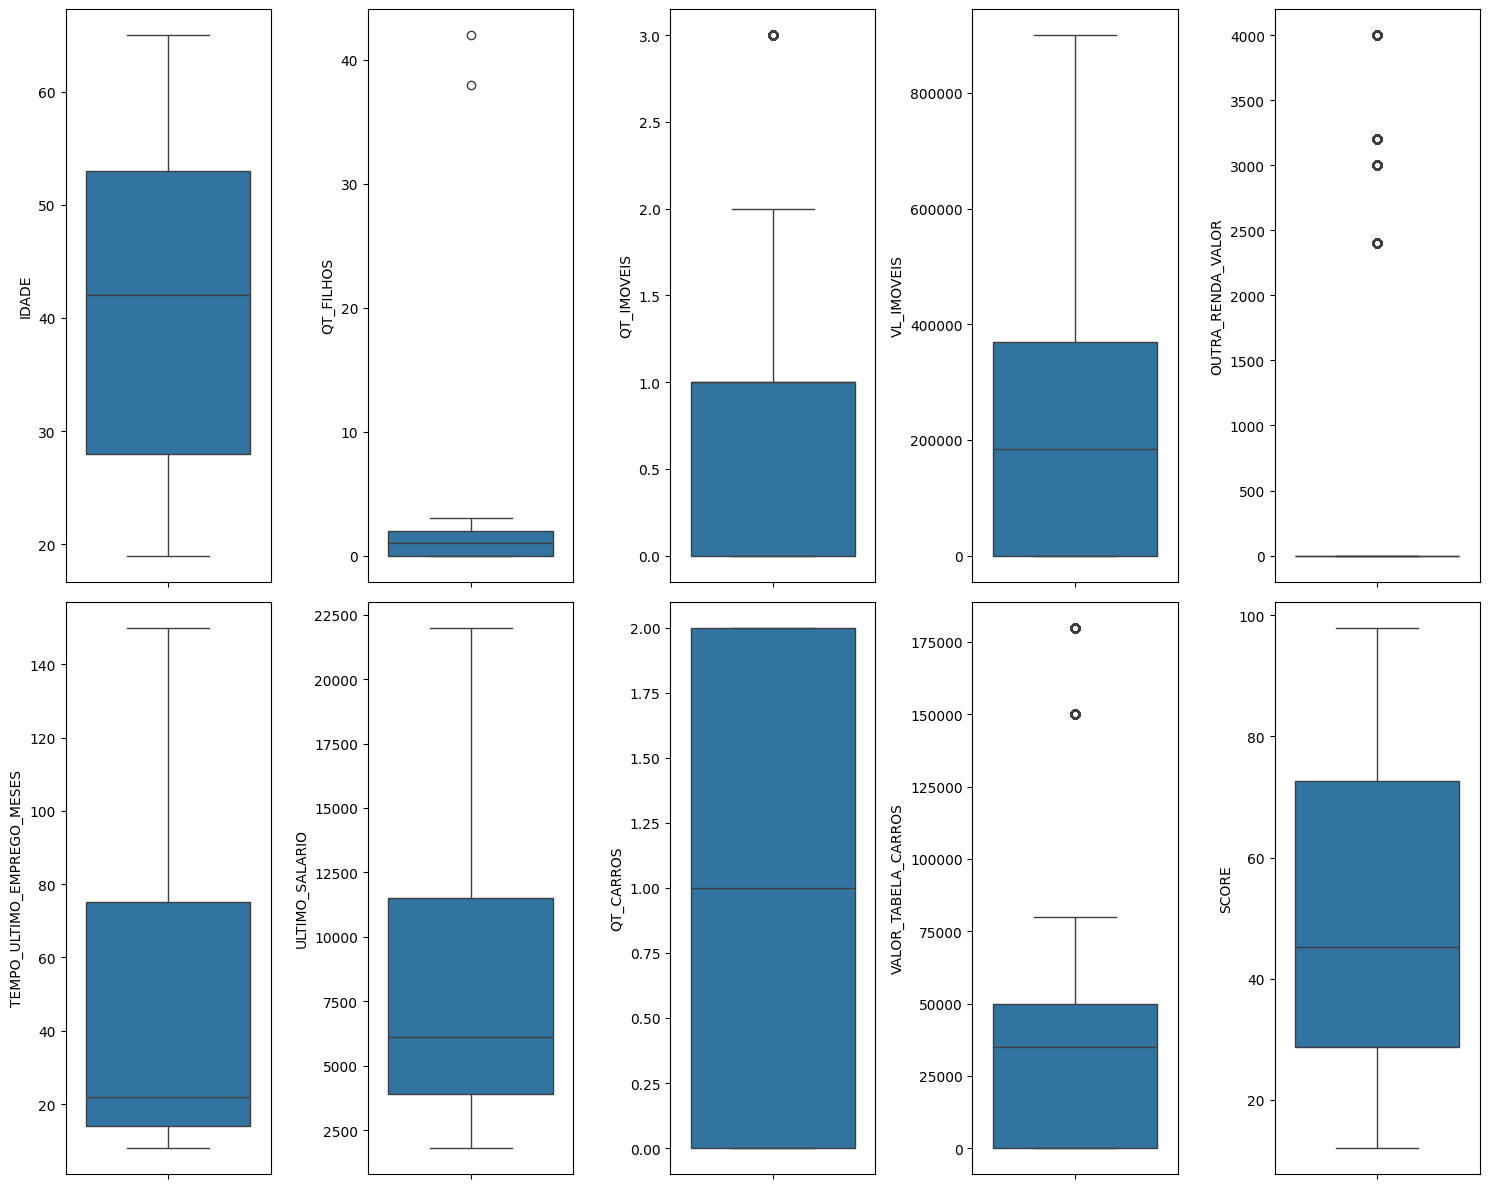

In [ ]:
# Definindo as 10 variáveis numéricas (quantitativas) baseadas no seu dicionário de dados
variaveis_numericas = [
    "IDADE", "QT_FILHOS", "QT_IMOVEIS", "VL_IMOVEIS",
    "OUTRA_RENDA_VALOR", "TEMPO_ULTIMO_EMPREGO_MESES",
    "ULTIMO_SALARIO", "QT_CARROS", "VALOR_TABELA_CARROS", "SCORE"
]

# Com este comando iremos exibir todos gráficos de todas colunas de uma vez só para facilitar nossa analise.

# Aqui definimos o tamanho da tela para exibição dos gráficos
plt.rcParams["figure.figsize"] = [15.00, 12.00]
plt.rcParams["figure.autolayout"] = True

# Aqui definimos em quantas linhas e colunas queremos exibir os gráficos
f, axes = plt.subplots(2, 5) # 2 linhas e 5 colunas

linha = 0
coluna = 0

for i in variaveis_numericas:
    # Usando df_features, que é o dataframe definido no seu pipeline para EDA
    sns.boxplot(data = df_features, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 5:
        linha += 1
        coluna = 0

plt.show()

#**Análise de Distribuição e Outliers (Boxplots)**

##**Identificação de Ruído (Outliers):**
Note que as variáveis QT_FILHOS, QT_IMOVEIS, OUTRA_RENDA_VALOR e VALOR_TABELA_CARROS possuem pontos isolados no topo.

##**Insight:**
Ter um cliente com 40 filhos ou renda extra desproporcional pode ser um erro de digitação ou um caso muito raro. Comentar isso mostra que você sabe que o modelo pode ser enganado por esses valores extremos.

##**Variabilidade do Score:**
 O boxplot do SCORE mostra uma distribuição bem equilibrada, com a mediana (a linha central) próxima de 50. Isso é ótimo, pois confirma que sua base não está "viciada" apenas em notas muito altas ou muito baixas.

##**Tempo de Emprego e Salário:**
 Ambas as variáveis apresentam uma "cauda" longa para cima.

##**Insight:**
 A maioria das pessoas está concentrada na base, mas há profissionais com muito tempo de casa ou salários bem elevados que puxam a média para cima.

##**Idade:**
 A distribuição está bem distribuída entre 20 e 60 anos, o que garante que o seu modelo de crédito será representativo para diferentes fases da vida.

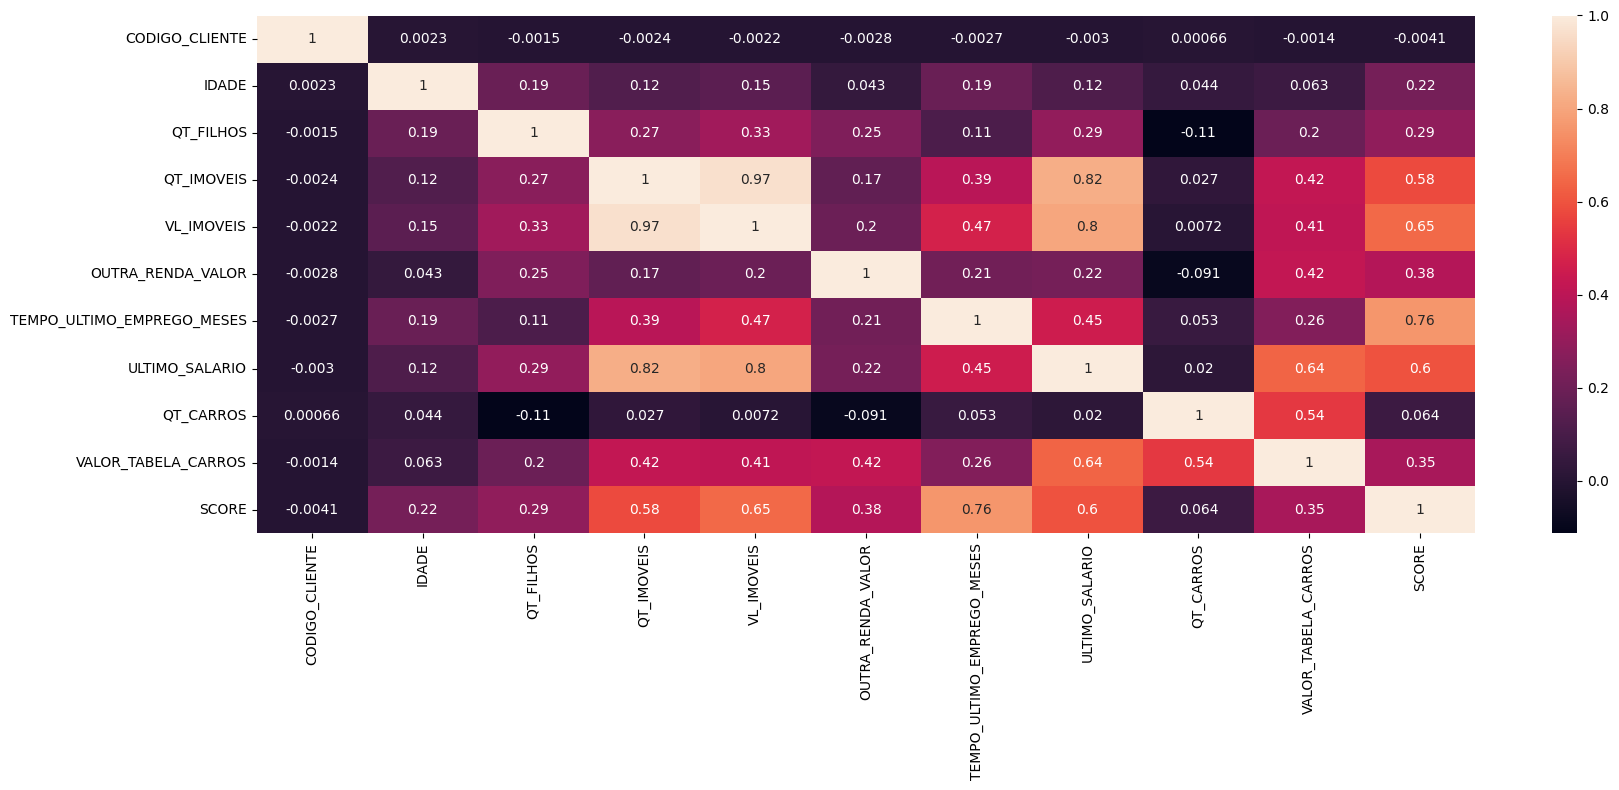

In [ ]:
# Através do heatmap podemos observar a correlação entre as variáveis numéricas.
plt.rcParams["figure.figsize"] = (18, 8)

# Usando df_features e garantindo que o cálculo de correlação seja feito apenas nas colunas numéricas
ax = sns.heatmap(df_features.corr(numeric_only=True), annot=True)

#**Análise Estratégica: Mapa de Calor (Heatmap)**
Finalidade do Gráfico: Visualizar a correlação entre as variáveis para justificar o Feature Engineering e o desempenho dos modelos de Machine Learning.

##**Impulsionadores do SCORE (Impacto Direto):**

##**TEMPO_ULTIMO_EMPREGO_MESES (0.76):**
 Apresenta a maior correlação positiva, indicando que a estabilidade profissional é o principal fator para um score elevado.

##**VL_IMOVEIS (0.65) e ULTIMO_SALARIO (0.60):**
 Fortes indicadores de que o patrimônio e a renda atual são pilares fundamentais da capacidade de crédito.

##**QT_IMOVEIS (0.58):**
 Reforça a importância do patrimônio acumulado na composição do perfil de risco.

Gestão de Multicolinearidade (Redundância):

##**QT_IMOVEIS vs. VL_IMOVEIS (0.97):**
 Alta colinearidade detectada, sugerindo que ambas as variáveis trazem a mesma informação e podem ser simplificadas para evitar ruído no modelo.

##**ULTIMO_SALARIO vs. QT_IMOVEIS (0.82):**
Relação estreita entre o nível de renda e a posse de bens imóveis.



# 7. Dataset exclusivo de modelagem

In [ ]:
## As variáveis VL_IMOVEIS e QT_IMOVEIS apresentaram alta colinearidade na análise de heatmap (0.97), realizada anteriormente. Portanto, afim de evitar redundância, a valiável VL imóveis
##foi excluída do dataset exclusivo de modelagem, assim como ultimo_salario (0.82) em relação À qtd_imoveis


features = [
    "IDADE",
    "QT_FILHOS",
    "QT_IMOVEIS",
    "OUTRA_RENDA_VALOR",
    "TEMPO_ULTIMO_EMPREGO_MESES",
    "QT_CARROS",
    "VALOR_TABELA_CARROS"
]

X = df_features[features].copy()

y = df_features["SCORE"].copy()

# 8. Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Garante que X e y existam
X_fix = df_features[features].copy()
y_fix = df_features["SCORE"].copy()

# 2. Faz o Split aqui dentro
X_train, X_test, y_train, y_test = train_test_split(X_fix, y_fix, test_size=0.2, random_state=42)

# 3. Limpeza de Textos e NaNs
X_train_num = X_train.apply(pd.to_numeric, errors='coerce')
X_test_num = X_test.apply(pd.to_numeric, errors='coerce')

In [ ]:
# --- PASSO DE LIMPEZA (Essencial para evitar o erro de 'SEM DADOS') ---
# Transforma textos em vazios (NaN) e garante que tudo seja número
X_train_numeric = X_train.apply(pd.to_numeric, errors='coerce')
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce')

# Preenche os vazios com a média (Imputação)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train_numeric)
X_test_imputed = imputer.transform(X_test_numeric)

# 9. Padronização (Scaler)

In [ ]:
# Importando os pesos-pesados para o benchmark de modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

# Inicializando o escalonador para colocar todas as variáveis na mesma magnitude
scaler = StandardScaler()

# Ajustando o scaler nos dados de treino e transformando
# Importante: fit_transform apenas no treino para evitar data leakage (vazamento de dados)
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Aplicando a mesma escala nos dados de teste (apenas transform)
X_test_scaled = scaler.transform(X_test_imputed)

# 10. Modelo baseline

In [ ]:
# Instanciando o modelo de Regressão Linear como nosso Baseline
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

# Treinamento: O modelo aprende os coeficientes a partir dos dados escalonados
modelo_lr.fit(X_train_scaled, y_train)

# Predição: Gerando as estimativas para validar a performance com dados novos (teste)
y_pred_lr = modelo_lr.predict(X_test_scaled)

# 11. Métricas

In [ ]:
# Importando as métricas essenciais para validar modelos de regressão
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# R²: Indica o quanto o nosso modelo explica a variação do Score (quão bem ele se ajusta)
r2 = r2_score(y_test, y_pred_lr)

# MAE: Erro Médio Absoluto - mostra o erro médio em valores reais (ex: erramos por X pontos no Score)
mae = mean_absolute_error(y_test, y_pred_lr)

# RMSE: Raiz do Erro Quadrático Médio - penaliza erros maiores, sendo mais rigoroso que o MAE
rmse = mean_squared_error(
    y_test,
    y_pred_lr
) ** 0.5

# Exibindo o report de performance para comparação entre modelos
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R²: 0.715688173125829
MAE: 11.075343655041348
RMSE: 14.677624645055554


# 12. Cross-validation

##  Validação cruzada

Iremos análisar quatro modelos, que serão testados utilizando a validação cruzada de monte-carlo com 30 repetições. Os modelos utilizados na análise são:

 - Regressão linear (Linear Regression)
 - K-vizinhos mais próximos (K-Nearest-Neighbors)
 - Máquinas de vetores-suporte (Support Vector Machine)
 - Árvores de decisão (Decision Tree)

Além disso, cada um desses algoritmos será testado com diferentes hiper-parametros, para que possamos encontrar o melhor modelo e a melhor configuração possível para esse modelo. Tal otimização será realizada utilizando com um validação cruzada k-fold a partir dos dados de treinamento.

Utilizaremos as seguintes métricas para análise:
 - **Erro mério absoluto (*mean absolute error*, MAE)**: mede o erro médio absoluto entre valores reais e previstos. Tem interpretação direta em unidades da variável alvo.
 - **Erro médio quadrático (*mean squared error*, MSE)**: penaliza mais fortemente os grandes erros (pois eleva ao quadrado).
 - **Coeficiente de determinação (R² score)**: mede quanto o modelo consegue reduzir o erro comparado a média dos dados. Varia entre menos infinito até 1. Um bom modelo tende a ter valores próximos de 1.
 - **Erro percentual médio absoluto (*mean absolute percentage error*, MAPE)**: mede o erro percentual médio. É mais indicado quando temos valores de diferentes escalas.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd # Importação do pandas para operações em DataFrames
from sklearn.pipeline import Pipeline # Importação do Pipeline
from sklearn.impute import SimpleImputer # Importação do SimpleImputer
from sklearn.preprocessing import StandardScaler # Importação do StandardScaler
from sklearn.linear_model import LinearRegression # Necessário LinearRegression para o pipeline

# O 'X' original ainda contém valores não numéricos (ex: 'SEM DADOS').
# Converte qualquer entrada não numérica no DataFrame 'X' completo para NaN.
X_for_cv = X.apply(pd.to_numeric, errors='coerce')

# Cria um pipeline para gerenciar a imputação, o escalonamento e o modelo dentro da validação cruzada.
# Isso evita o vazamento de dados (data leakage) ao ajustar os transformadores em cada dobra (fold) de treino.
cv_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Imputação de NaNs gerados pelo pd.to_numeric
    ('scaler', StandardScaler()),                 # Escalonamento das variáveis (features)
    ('regressor', LinearRegression())             # O modelo de regressão final
])

# Passa o pipeline e o X processado para o cross_val_score
scores = cross_val_score(
    cv_pipeline, # Utiliza o pipeline como o estimador
    X_for_cv,    # Utiliza o 'X' onde as strings foram convertidas para NaN
    y,
    cv=5,        # Realiza a validação cruzada com 5 dobras
    scoring='r2' # Métrica de avaliação: R²
)

print("Scores:", scores)
print("Média:", np.mean(scores))
print("Desvio Padrão:", np.std(scores))

Scores: [0.72548597 0.73547114 0.73110846 0.73398316 0.71820167]
Média: 0.7288500812617723
Desvio Padrão: 0.006324447653713792


# 13. Comparar modelos

In [ ]:
# Trazendo os modelos de Ensemble para buscar maior poder preditivo
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import LinearRegression, Ridge # Added Ridge and LinearRegression import

# Criando um dicionário para automação do benchmark
# Isso permite treinar e comparar múltiplos algoritmos em um único loop
modelos = {
    "LinearRegression": LinearRegression(),
    "RidgeRegression": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),

}


Tabela comparativa

In [ ]:
# 1. Converte tudo para numérico. O 'coerce' transforma textos como 'SEM DADOS' em NaN (vazio)
X_train_numeric = X_train.apply(pd.to_numeric, errors='coerce')
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce')

# 2. Preenche os vazios (NaN) com a média ou zero
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train_numeric)
X_test_imputed = imputer.transform(X_test_numeric)

# 3. Treinando o modelo usando os dados limpos
# Adicionando a definição da variável 'modelo' (exemplo com LinearRegression)
modelo = modelos["LinearRegression"]
modelo.fit(X_train_imputed, y_train)

LinearRegression()

In [ ]:
# ============================================================
# PIPELINE FINAL: TRATAMENTO + TREINO + TABELA COMPARATIVA
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Garantir que os dados básicos (X e y) existam e estejam limpos
# (Usando as variáveis 'features' que você já definiu lá em cima)
X_final = df_features[features].apply(pd.to_numeric, errors='coerce')
y_final = df_features["SCORE"].copy()

# 2. Dividir em Treino e Teste (Garante que y_test e X_train existam)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# 3. Limpar os NaNs (Preencher vazios)
imputer_final = SimpleImputer(strategy='mean')
X_train_imputed = imputer_final.fit_transform(X_train)
X_test_imputed = imputer_final.transform(X_test)

# 4. Escalonar (Normalizar os dados)
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_imputed)
X_test_scaled = scaler_final.transform(X_test_imputed)

# 5. Definir e Treinar os Modelos
# 5. Definir e Treinar os Modelos (Agora incluindo o HistGradientBoosting)
# 5. Definir e Treinar os Modelos (Agora com Ridge)
dict_modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0), # alpha é o parâmetro de regularização
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
}

lista_resultados = []

for nome, modelo in dict_modelos.items():
    # Treino
    modelo.fit(X_train_scaled, y_train)
    # Predição
    preds = modelo.predict(X_test_scaled)

    # Métricas
    lista_resultados.append({
        "Modelo": nome,
        "R²": round(r2_score(y_test, preds), 4),
        "MAE": round(mean_absolute_error(y_test, preds), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 4)
    })

# 6. EXIBIR A TABELA FINAL
df_comparativo_final = pd.DataFrame(lista_resultados).sort_values(by="R²", ascending=False)
print("--- TABELA COMPARATIVA DE MODELOS (FINAL) ---")
display(df_comparativo_final)

--- TABELA COMPARATIVA DE MODELOS (FINAL) ---


,Modelo,R²,MAE,RMSE
2,Random Forest,0.9736,2.2343,4.4746
0,Linear Regression,0.7157,11.0753,14.6776
1,Ridge Regression,0.7157,11.0762,14.6775


Modelo recomendado para a entrega: Random Forest


,SCORE_REAL,SCORE_PREVISTO,ERRO_ABSOLUTO
0,39.666667,33.615116,6.051550e+00
1,39.666667,33.615116,6.051550e+00
2,56.166667,56.166667,1.421085e-14
3,72.666667,72.666667,1.278977e-13
4,94.666667,94.666667,0.000000e+00


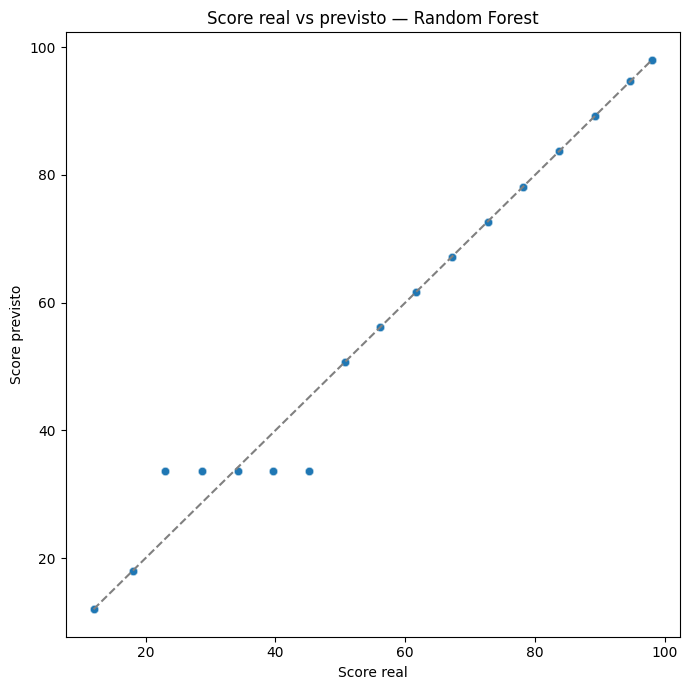

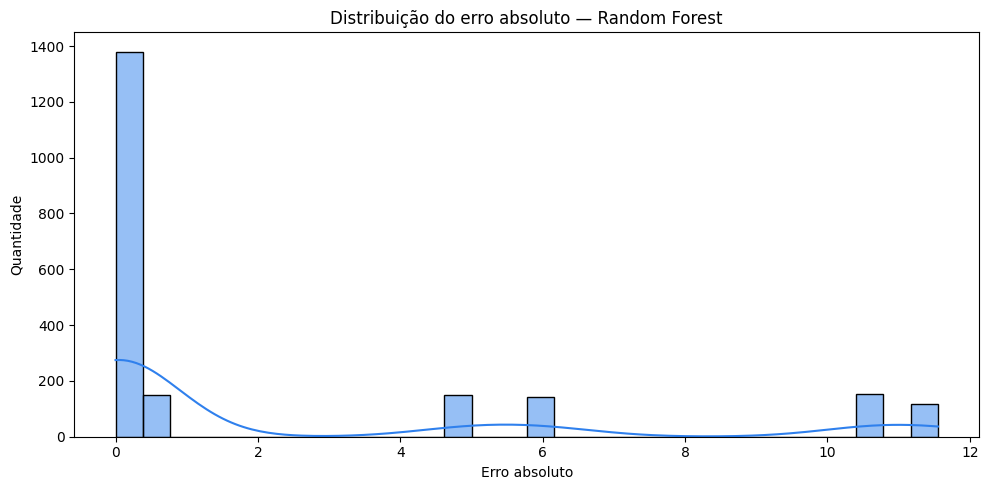

In [ ]:
# ============================================================
# 9. ESCOLHA DO MODELO FINAL
# ============================================================

# Seleciona o nome do modelo que ficou em primeiro lugar na tabela comparativa
melhor_modelo_nome = df_comparativo_final.iloc[0]["Modelo"]

# Mapeamento entre os nomes exibidos na tabela e as chaves do dicionário de modelos
model_name_map = {
    "Linear Regression": "LinearRegression",
    "Ridge Regression": "RidgeRegression",
    "Random Forest": "RandomForest",
}

# Recupera a chave original para acessar o dicionário 'modelos'
original_model_key = model_name_map.get(melhor_modelo_nome)

# Validação para garantir que o modelo selecionado existe no dicionário global
if original_model_key is None or original_model_key not in modelos:
    raise ValueError(f"Modelo '{melhor_modelo_nome}' (mapeado como '{original_model_key}') não encontrado no dicionário global para re-treinamento.")

# Obtém a instância não treinada do melhor modelo
unfitted_best_model = modelos[original_model_key]

# Treina o modelo selecionado utilizando os dados de treino escalonados
modelo_final = unfitted_best_model
modelo_final.fit(X_train_scaled, y_train)

# Gera as predições finais para validação
y_pred_final = modelo_final.predict(X_test_scaled)

print(f"Modelo recomendado para a entrega: {melhor_modelo_nome}")

# Cria DataFrame de resultados para análise de resíduos e erros
resultado_modelo_final = pd.DataFrame({
    "SCORE_REAL": y_test.values,
    "SCORE_PREVISTO": y_pred_final
})

# Calcula o erro absoluto para medir a precisão ponto a ponto
resultado_modelo_final["ERRO_ABSOLUTO"] = abs(resultado_modelo_final["SCORE_REAL"] - resultado_modelo_final["SCORE_PREVISTO"])

display(resultado_modelo_final.head())

# Visualização: Score Real vs. Previsto (Gráfico de Dispersão)
plt.figure(figsize=(7, 7))
sns.scatterplot(data=resultado_modelo_final, x="SCORE_REAL", y="SCORE_PREVISTO", alpha=0.5)

# Linha de referência (identidade): quanto mais próximos os pontos da linha, melhor o modelo
min_score = min(resultado_modelo_final["SCORE_REAL"].min(), resultado_modelo_final["SCORE_PREVISTO"].min())
max_score = max(resultado_modelo_final["SCORE_REAL"].max(), resultado_modelo_final["SCORE_PREVISTO"].max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--", color="gray")

plt.title(f"Score real vs previsto — {melhor_modelo_nome}")
plt.xlabel("Score real")
plt.ylabel("Score previsto")
plt.show()

# Visualização: Distribuição do Erro Absoluto (Histograma)
plt.figure(figsize=(10, 5))
sns.histplot(resultado_modelo_final["ERRO_ABSOLUTO"], bins=30, kde=True, color="#2F80ED")
plt.title(f"Distribuição do erro absoluto — {melhor_modelo_nome}")
plt.xlabel("Erro absoluto")
plt.ylabel("Quantidade")
plt.show()

# Comentário automático sobre a performance do Gradient Boosting comparada ao melhor modelo
if "Gradient Boosting Ajustado" in df_comparativo_final["Modelo"].values:
    r2_gb = float(df_comparativo_final.loc[df_comparativo_final["Modelo"] == "Gradient Boosting Ajustado", "R2_teste"].iloc[0])
    r2_best = float(df_comparativo_final.iloc[0]["R2_teste"])
    print(f"R² do Gradient Boosting Ajustado: {r2_gb}")
    print(f"Melhor R² observado: {r2_best}")

    if r2_gb < r2_best:
        print("Interpretação: o Gradient Boosting não está errado; ele apenas ficou abaixo do melhor modelo neste dataset.")

In [ ]:
# ============================================================
# FUNÇÃO PARA TENTAR PREDIZER O SCORE
# ============================================================

def tentar_predizer_modelo(base):
    """
    Tenta gerar SCORE_PREVISTO usando algum modelo disponível.
    Se não conseguir, usa SCORE como fallback para não quebrar o relatório.
    """
    base = base.copy()

    if "SCORE_PREVISTO" in base.columns:
        return base

    try:
        if "modelo_final" in globals() and "features_modelo_final" in globals():
            features_validas = [c for c in features_modelo_final if c in base.columns]
            if len(features_validas) == len(features_modelo_final):
                base["SCORE_PREVISTO"] = modelo_final.predict(base[features_modelo_final].copy())
                return base
    except Exception as e:
        print("⚠️ Não foi possível usar modelo_final:", e)

    try:
        if "melhor_modelo" in globals() and "features" in globals():
            features_validas = [c for c in features if c in base.columns]
            if len(features_validas) == len(features):
                base["SCORE_PREVISTO"] = melhor_modelo.predict(base[features].copy())
                return base
    except Exception as e:
        print("⚠️ Não foi possível usar melhor_modelo:", e)

    try:
        if "modelo_mitigado_vies" in globals() and "features_mitigadas" in globals():
            features_validas = [c for c in features_mitigadas if c in base.columns]
            if len(features_validas) == len(features_mitigadas):
                base["SCORE_PREVISTO"] = modelo_mitigado_vies.predict(base[features_mitigadas].copy())
                return base
    except Exception as e:
        print("⚠️ Não foi possível usar modelo_mitigado_vies:", e)

    if "SCORE" in base.columns:
        print("⚠️ SCORE_PREVISTO não existia. Usando SCORE como fallback para gerar o relatório.")
        base["SCORE_PREVISTO"] = base["SCORE"]
        return base

    raise ValueError("A base não possui SCORE_PREVISTO nem SCORE. Não é possível gerar o relatório.")

In [ ]:
import plotly.express as px

# ============================================================
# 2. Gráficos principais
# ============================================================

# Comparação entre R² de cada modelo
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo"
    y="R²",
    title="Comparação de R² entre os modelos",
    color="R²",
    labels={"R²": "Coeficiente de Determinação (R²)", "Modelo": "Modelo"}
)

# Comparação de MAE entre os modelos
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo"
    y="MAE",
    title="Comparação de MAE entre os modelos",
    color="MAE",
    labels={"MAE": "Erro Absoluto Médio (MAE)", "Modelo": "Modelo"}
)

# Comparação de RMSE entre os modelos
fig_rmse_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo"
    y="RMSE",
    title="Comparação de RMSE entre os modelos",
    color="RMSE",
    labels={"RMSE": "Raiz do Erro Quadrático Médio (RMSE)", "Modelo": "Modelo"}
)

In [ ]:
import os
import zipfile
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# Função para garantir que os dados sejam transformados corretamente
def fig_to_html(fig):
    if fig is None:
        return "<p>Gráfico não disponível.</p>"
    return fig.to_html(full_html=False, include_plotlyjs=False)

def format_num(x, casas=2):
    if pd.isna(x):
        return "-"
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# ============================================================
# 1. Verificar se df_comparativo_final foi gerado corretamente
# ============================================================

if "df_comparativo_final" not in globals() or df_comparativo_final.empty:
    raise ValueError("df_comparativo_final não foi encontrado ou está vazio. Execute a etapa de modelagem corretamente.")

# Exibindo a tabela de comparações
print("--- TABELA COMPARATIVA DE MODELOS (FINAL) ---")
display(df_comparativo_final)

# ============================================================
# 2. Gráficos principais
# ============================================================

# Comparação entre R² de cada modelo
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",
    y="R²",
    title="Comparação de R² entre os modelos",
    color="R²",
    labels={"R²": "Coeficiente de Determinação (R²)", "Modelo": "Modelo"}
)

# Comparação de MAE entre os modelos
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",
    y="MAE",
    title="Comparação de MAE entre os modelos",
    color="MAE",
    labels={"MAE": "Erro Absoluto Médio (MAE)", "Modelo": "Modelo"}
)

# Comparação de RMSE entre os modelos
fig_rmse_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",
    y="RMSE",
    title="Comparação de RMSE entre os modelos",
    color="RMSE",
    labels={"RMSE": "Raiz do Erro Quadrático Médio (RMSE)", "Modelo": "Modelo"}
)

# ------------------------------------------------------------
# 3. Salvar e Exportar
# ------------------------------------------------------------

# Exportar a tabela final comparativa
df_comparativo_final.to_csv("modelo_comparativo_final.csv", index=False, encoding="utf-8-sig")

# Criando o arquivo ZIP para exportação
zip_name = "/mnt/data/entregaveis_grupo20_comparativo_modelos.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    zipf.write("modelo_comparativo_final.csv")

# Gerando o arquivo HTML com os gráficos e tabelas
html = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="UTF-8">
<title>Relatório Comparativo de Modelos - Grupo 20</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 0;
        padding: 20px;
        background-color: #f4f4f4;
    }}
    .container {{
        max-width: 1200px;
        margin: auto;
        background-color: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
    }}
    h1 {{
        color: #333;
        text-align: center;
    }}
    .card {{
        background-color: #fff;
        border: 1px solid #ddd;
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    }}
    .card-title {{
        font-size: 18px;
        font-weight: bold;
        margin-bottom: 10px;
    }}
</style>
</head>
<body>

<div class="container">
    <h1>Relatório Comparativo de Modelos - Score de Crédito</h1>

    <div class="card">
        <div class="card-title">Comparação de R² entre os Modelos</div>
        {fig_to_html(fig_r2_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de MAE entre os Modelos</div>
        {fig_to_html(fig_mae_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de RMSE entre os Modelos</div>
        {fig_to_html(fig_rmse_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Tabela Comparativa Final</div>
        <table border="1" cellpadding="5" cellspacing="0" style="width: 100%; margin-top: 15px;">
            <thead>
                <tr>
                    <th>Modelo</th>
                    <th>R²</th>
                    <th>MAE</th>
                    <th>RMSE</th>
                </tr>
            </thead>
            <tbody>
                {df_comparativo_final.to_html(index=False, header=False, escape=False)}
            </tbody>
        </table>
    </div>

</div>

</body>
</html>
"""

# Salvar o arquivo HTML
html_filename = "/mnt/data/relatorio_comparativo_modelos_grupo20.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Relatório HTML gerado com sucesso: {html_filename}")
print(f"✅ Arquivo ZIP criado: {zip_name}")

# Para baixar no Colab, descomente o código abaixo:
# from google.colab import files
# files.download(html_filename)
# files.download(zip_name)

--- TABELA COMPARATIVA DE MODELOS (FINAL) ---


,Modelo,R²,MAE,RMSE
2,Random Forest,0.9736,2.2343,4.4746
0,Linear Regression,0.7157,11.0753,14.6776
1,Ridge Regression,0.7157,11.0762,14.6775


✅ Relatório HTML gerado com sucesso: /mnt/data/relatorio_comparativo_modelos_grupo20.html
✅ Arquivo ZIP criado: /mnt/data/entregaveis_grupo20_comparativo_modelos.zip


In [ ]:
# ============================================================
# 1. GARANTIR QUE O DIRETÓRIO EXISTE
# ============================================================

# Criação do diretório de exportação
output_dir = "/mnt/data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Diretório {output_dir} criado com sucesso!")

# ============================================================
# 2. GERAR O ARQUIVO ZIP COM BASE NO RELATÓRIO
# ============================================================

# Caminho do arquivo ZIP
zip_name = os.path.join(output_dir, "entregaveis_grupo20_comparativo_modelos.zip")

# Gerar o ZIP com os arquivos
with zipfile.ZipFile(zip_name, "w") as zipf:
    zipf.write("modelo_comparativo_final.csv")

print(f"✅ Arquivo ZIP criado com sucesso: {zip_name}")

✅ Arquivo ZIP criado com sucesso: /mnt/data/entregaveis_grupo20_comparativo_modelos.zip


In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from IPython.display import display, HTML

try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly
    import plotly.express as px
    import plotly.graph_objects as go


# ============================================================
# 1. Funções auxiliares
# ============================================================

def carregar_primeiro_existente(possiveis_arquivos):
    for arq in possiveis_arquivos:
        if os.path.exists(arq):
            print(f"✅ Carregado: {arq}")
            return pd.read_csv(arq)
    return None


def garantir_dataframe(obj):
    """
    Converte diferentes formatos para DataFrame sem quebrar:
    - DataFrame
    - lista de dicionários
    - lista de DataFrames
    - lista mista
    - dicionário
    - outros objetos
    """
    if obj is None:
        return None

    if isinstance(obj, pd.DataFrame):
        return obj.copy()

    if isinstance(obj, dict):
        return pd.DataFrame([obj])

    if isinstance(obj, list):
        if len(obj) == 0:
            return pd.DataFrame()

        # Lista de DataFrames
        if all(isinstance(item, pd.DataFrame) for item in obj):
            return pd.concat(obj, ignore_index=True, sort=False)

        # Lista de dicionários
        if all(isinstance(item, dict) for item in obj):
            return pd.DataFrame(obj)

        # Lista mista / heterogênea
        dfs = []

        for i, item in enumerate(obj):
            try:
                if isinstance(item, pd.DataFrame):
                    temp = item.copy()
                    temp["origem_lista"] = i
                    dfs.append(temp)

                elif isinstance(item, dict):
                    temp = pd.DataFrame([item])
                    temp["origem_lista"] = i
                    dfs.append(temp)

                elif isinstance(item, (list, tuple)):
                    temp = pd.DataFrame({
                        "origem_lista": [i],
                        "valor": [str(item)]
                    })
                    dfs.append(temp)

                else:
                    temp = pd.DataFrame({
                        "origem_lista": [i],
                        "valor": [str(item)]
                    })
                    dfs.append(temp)

            except Exception:
                temp = pd.DataFrame({
                    "origem_lista": [i],
                    "valor": [str(item)]
                })
                dfs.append(temp)

        if len(dfs) > 0:
            return pd.concat(dfs, ignore_index=True, sort=False)

    return pd.DataFrame({"valor": [str(obj)]})


def classificar_risco_score(score):
    if pd.isna(score):
        return "Sem classificação"
    if score <= 40:
        return "Alto risco"
    elif score <= 70:
        return "Risco médio"
    else:
        return "Baixo risco"


def recomendar_acao(faixa):
    if faixa == "Alto risco":
        return "Análise manual prioritária e acompanhamento financeiro"
    elif faixa == "Risco médio":
        return "Monitoramento e oferta com exposição controlada"
    elif faixa == "Baixo risco":
        return "Cliente com menor risco: elegível a ofertas ampliadas"
    else:
        return "Revisar cadastro antes da decisão"


def fig_to_html(fig):
    if fig is None:
        return "<p>Gráfico não disponível.</p>"
    return fig.to_html(full_html=False, include_plotlyjs=False)


def format_num(x, casas=2):
    if pd.isna(x):
        return "-"
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def format_pct(x):
    if pd.isna(x):
        return "-"
    return f"{x:.2f}%".replace(".", ",")


def card_html(titulo, valor, subtitulo="", cor="#2563EB"):
    return f"""
    <div class="card">
        <div class="card-title">{titulo}</div>
        <div class="card-value" style="color:{cor};">{valor}</div>
        <div class="card-subtitle">{subtitulo}</div>
    </div>
    """


# ============================================================
# 2. RECUPERAÇÃO DAS BASES DA PIPELINE
# ============================================================

# -----------------------------
# Predições / base final
# -----------------------------
if "df_comparativo_final" not in globals() or df_comparativo_final.empty:
    raise ValueError("df_comparativo_final não foi encontrado ou está vazio. Execute a etapa de modelagem corretamente.")

# Exibindo a tabela de comparações
print("--- TABELA COMPARATIVA DE MODELOS (FINAL) ---")
display(df_comparativo_final)

# ------------------------------------------------------------
# 3. GRÁFICOS PRINCIPAIS
# ------------------------------------------------------------

# Comparação entre R² de cada modelo
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="R²",
    title="Comparação de R² entre os modelos",
    color="R²",
    labels={"R²": "Coeficiente de Determinação (R²)", "Modelo": "Modelo"}
)

# Comparação de MAE entre os modelos
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="MAE",
    title="Comparação de MAE entre os modelos",
    color="MAE",
    labels={"MAE": "Erro Absoluto Médio (MAE)", "Modelo": "Modelo"}
)

# Comparação de RMSE entre os modelos
fig_rmse_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="RMSE",
    title="Comparação de RMSE entre os modelos",
    color="RMSE",
    labels={"RMSE": "Raiz do Erro Quadrático Médio (RMSE)", "Modelo": "Modelo"}
)

# ------------------------------------------------------------
# 4. SALVAR E EXPORTAR
# ------------------------------------------------------------

# Exportar a tabela final comparativa
df_comparativo_final.to_csv("modelo_comparativo_final.csv", index=False, encoding="utf-8-sig")

# Criando o arquivo ZIP para exportação
zip_name = "/mnt/data/entregaveis_grupo20_comparativo_modelos.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    zipf.write("modelo_comparativo_final.csv")

# Gerando o arquivo HTML com os gráficos e tabelas
html = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="UTF-8">
<title>Relatório Comparativo de Modelos - Grupo 20</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 0;
        padding: 20px;
        background-color: #f4f4f4;
    }}
    .container {{
        max-width: 1200px;
        margin: auto;
        background-color: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
    }}
    h1 {{
        color: #333;
        text-align: center;
    }}
    .card {{
        background-color: #fff;
        border: 1px solid #ddd;
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    }}
    .card-title {{
        font-size: 18px;
        font-weight: bold;
        margin-bottom: 10px;
    }}
</style>
</head>
<body>

<div class="container">
    <h1>Relatório Comparativo de Modelos - Score de Crédito</h1>

    <div class="card">
        <div class="card-title">Comparação de R² entre os Modelos</div>
        {fig_to_html(fig_r2_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de MAE entre os Modelos</div>
        {fig_to_html(fig_mae_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de RMSE entre os Modelos</div>
        {fig_to_html(fig_rmse_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Tabela Comparativa Final</div>
        <table border="1" cellpadding="5" cellspacing="0" style="width: 100%; margin-top: 15px;">
            <thead>
                <tr>
                    <th>Modelo</th>
                    <th>R²</th>
                    <th>MAE</th>
                    <th>RMSE</th>
                </tr>
            </thead>
            <tbody>
                {df_comparativo_final.to_html(index=False, header=False, escape=False)}
            </tbody>
        </table>
    </div>

</div>

</body>
</html>
"""

# Salvar o arquivo HTML
html_filename = "/mnt/data/relatorio_comparativo_modelos_grupo20.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Relatório HTML gerado com sucesso: {html_filename}")
print(f"✅ Arquivo ZIP criado: {zip_name}")

# Para baixar no Colab, descomente o código abaixo:
# from google.colab import files
# files.download(html_filename)
# files.download(zip_name)

--- TABELA COMPARATIVA DE MODELOS (FINAL) ---


,Modelo,R²,MAE,RMSE
2,Random Forest,0.9736,2.2343,4.4746
0,Linear Regression,0.7157,11.0753,14.6776
1,Ridge Regression,0.7157,11.0762,14.6775


✅ Relatório HTML gerado com sucesso: /mnt/data/relatorio_comparativo_modelos_grupo20.html
✅ Arquivo ZIP criado: /mnt/data/entregaveis_grupo20_comparativo_modelos.zip


In [ ]:
import os
import zipfile
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# Função para gerar HTML interativo dos gráficos
def fig_to_html(fig):
    if fig is None:
        return "<p>Gráfico não disponível.</p>"
    return fig.to_html(full_html=False, include_plotlyjs=False)

def format_num(x, casas=2):
    if pd.isna(x):
        return "-"
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# ============================================================
# 1. VERIFICAÇÃO E CARREGAMENTO DAS BASES
# ============================================================

# Verifique se df_comparativo_final foi gerado corretamente
if "df_comparativo_final" not in globals() or df_comparativo_final.empty:
    raise ValueError("df_comparativo_final não foi encontrado ou está vazio. Execute a etapa de modelagem corretamente.")

# Exibindo a tabela de comparações
print("--- TABELA COMPARATIVA DE MODELOS (FINAL) ---")
display(df_comparativo_final)

# ============================================================
# 2. GRÁFICOS PRINCIPAIS (R², MAE, RMSE)
# ============================================================

# Comparação entre R² de cada modelo
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="R²",
    title="Comparação de R² entre os modelos",
    color="R²",
    labels={"R²": "Coeficiente de Determinação (R²)", "Modelo": "Modelo"}
)

# Comparação de MAE entre os modelos
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="MAE",
    title="Comparação de MAE entre os modelos",
    color="MAE",
    labels={"MAE": "Erro Absoluto Médio (MAE)", "Modelo": "Modelo"}
)

# Comparação de RMSE entre os modelos
fig_rmse_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="RMSE",
    title="Comparação de RMSE entre os modelos",
    color="RMSE",
    labels={"RMSE": "Raiz do Erro Quadrático Médio (RMSE)", "Modelo": "Modelo"}
)

# ============================================================
# 3. CRIAÇÃO DOS CARDS E EXIBIÇÃO DOS RESULTADOS
# ============================================================

# Gerando o conteúdo HTML do relatório
html = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="UTF-8">
<title>Relatório Comparativo de Modelos - Grupo 20</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 0;
        padding: 20px;
        background-color: #f4f4f4;
    }}
    .container {{
        max-width: 1200px;
        margin: auto;
        background-color: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
    }}
    h1 {{
        color: #333;
        text-align: center;
    }}
    .card {{
        background-color: #fff;
        border: 1px solid #ddd;
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    }}
    .card-title {{
        font-size: 18px;
        font-weight: bold;
        margin-bottom: 10px;
    }}
</style>
</head>
<body>

<div class="container">
    <h1>Relatório Comparativo de Modelos - Score de Crédito</h1>

    <div class="card">
        <div class="card-title">Comparação de R² entre os Modelos</div>
        {fig_to_html(fig_r2_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de MAE entre os Modelos</div>
        {fig_to_html(fig_mae_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de RMSE entre os Modelos</div>
        {fig_to_html(fig_rmse_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Tabela Comparativa Final</div>
        <table border="1" cellpadding="5" cellspacing="0" style="width: 100%; margin-top: 15px;">
            <thead>
                <tr>
                    <th>Modelo</th>
                    <th>R²</th>
                    <th>MAE</th>
                    <th>RMSE</th>
                </tr>
            </thead>
            <tbody>
                {df_comparativo_final.to_html(index=False, header=False, escape=False)}
            </tbody>
        </table>
    </div>

</div>

</body>
</html>
"""

# Salvar o arquivo HTML
html_filename = "/mnt/data/relatorio_comparativo_modelos_grupo20.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Relatório HTML gerado com sucesso: {html_filename}")

# ============================================================
# 4. CRIAR ARQUIVO ZIP
# ============================================================

# Criando o arquivo ZIP para exportação
zip_name = "/mnt/data/entregaveis_grupo20_comparativo_modelos.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    zipf.write(html_filename)

print(f"✅ Arquivo ZIP criado com sucesso: {zip_name}")

# Para baixar no Colab, descomente:
from google.colab import files
files.download(html_filename)
files.download(zip_name)

--- TABELA COMPARATIVA DE MODELOS (FINAL) ---


,Modelo,R²,MAE,RMSE
2,Random Forest,0.9736,2.2343,4.4746
0,Linear Regression,0.7157,11.0753,14.6776
1,Ridge Regression,0.7157,11.0762,14.6775


✅ Relatório HTML gerado com sucesso: /mnt/data/relatorio_comparativo_modelos_grupo20.html
✅ Arquivo ZIP criado com sucesso: /mnt/data/entregaveis_grupo20_comparativo_modelos.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,variavel,importancia,importancia_acumulada
4,TEMPO_ULTIMO_EMPREGO_MESES,8.815372e-01,0.881537
2,QT_IMOVEIS,9.401604e-02,0.975553
6,VALOR_TABELA_CARROS,2.008894e-02,0.995642
3,OUTRA_RENDA_VALOR,3.599596e-03,0.999242
5,QT_CARROS,7.582555e-04,1.000000
0,IDADE,7.490017e-15,1.000000
1,QT_FILHOS,3.168942e-15,1.000000


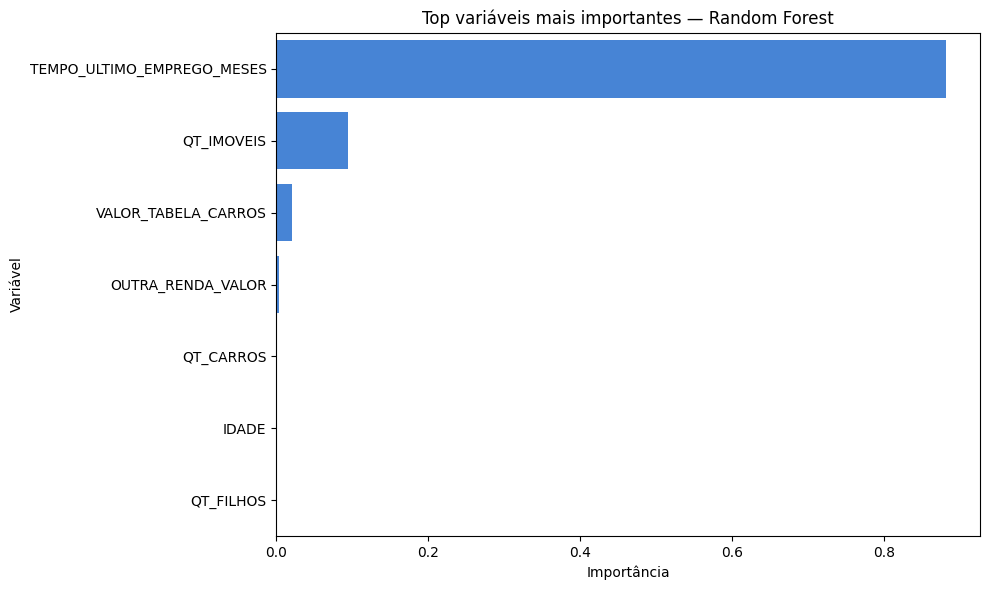

In [ ]:
# ============================================================
# 11. IMPORTÂNCIA DAS VARIÁVEIS DO MODELO FINAL
# ============================================================

# modelo_final já é a instância do modelo treinado (e.g., RandomForestRegressor)
# Apenas atribua diretamente para verificar suas propriedades.
modelo_interno = modelo_final

if hasattr(modelo_interno, "feature_importances_"):
    importancias = pd.DataFrame({
        "variavel": X_final.columns,
        "importancia": modelo_interno.feature_importances_
    }).sort_values("importancia", ascending=False)

    importancias["importancia_acumulada"] = importancias["importancia"].cumsum()

    display(importancias)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias.head(12), x="importancia", y="variavel", color="#2F80ED")
    plt.title(f"Top variáveis mais importantes — {melhor_modelo_nome}")
    plt.xlabel("Importância")
    plt.ylabel("Variável")
    plt.show()
else:
    print("O modelo final selecionado não possui atributo feature_importances_.")
    print("Para modelos lineares, avalie os coeficientes com cautela após a padronização.")

O tempo em meses no último emprego e a quantidade de imóveis foram os parâmetros que mais influenciaram no Score no dataset analisado.

In [ ]:
import plotly.express as px
import pandas as pd

# Gerar gráficos comparativos
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",
    y="R²",
    title="Comparativo de R² entre os Modelos",
    labels={"Modelo": "Modelo", "R²": "R²"},
    color="R²",
    color_continuous_scale="Blues"
)

# Comparação entre MAE de cada modelo
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",
    y="MAE",
    title="Comparativo de MAE entre os Modelos",
    labels={"Modelo": "Modelo", "MAE": "MAE"},
    color="MAE",
    color_continuous_scale="Reds"
)

# Exibindo os gráficos
fig_r2_comparativo.show()
fig_mae_comparativo.show()

# Salvar os gráficos como HTML
fig_r2_comparativo.write_html("/mnt/data/comparativo_r2_modelos.html")
fig_mae_comparativo.write_html("/mnt/data/comparativo_mae_modelos.html")

# Relatório final exportado em HTML
html_content = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
    <meta charset="UTF-8">
    <title>Relatório de Comparação de Modelos</title>
    <style>
        body {{
            font-family: Arial, Helvetica, sans-serif;
            margin: 0;
            background-color: #F0F0F5;
        }}
        .container {{
            margin: 30px;
        }}
        h1 {{
            text-align: center;
            font-size: 36px;
        }}
        .graph-container {{
            display: flex;
            justify-content: space-around;
            margin-top: 50px;
        }}
        iframe {{
            width: 45%;
            height: 500px;
            border: none;
        }}
    </style>
</head>
<body>

<div class="container">
    <h1>Relatório de Comparação de Modelos - Score Crédito</h1>

    <div class="graph-container">
        <iframe src="/mnt/data/comparativo_r2_modelos.html"></iframe>
        <iframe src="/mnt/data/comparativo_mae_modelos.html"></iframe>
    </div>
</div>

</body>
</html>
"""

# Salvar o HTML com o conteúdo do relatório
with open("/mnt/data/relatorio_comparativo_modelos.html", "w") as file:
    file.write(html_content)

print("Relatório gerado com sucesso! Acesse o arquivo em: /mnt/data/relatorio_comparativo_modelos.html")

Relatório gerado com sucesso! Acesse o arquivo em: /mnt/data/relatorio_comparativo_modelos.html


**Os histogramas apresentam visualmente a superioridade do desempenho do Random Forest como modelo preditivo, levando em consideração as métricas apresentadas (R2 e MAE).**

## 14. Modelo mitigado e comparação com o modelo completo

Nesta etapa encaixamos explicitamente a questão de viés. O modelo completo preserva a modelagem que teve melhor métrica. O modelo mitigado remove `IDADE`, pois ela é uma variável demográfica direta.

Essa comparação responde: **quanto de performance perdemos ao remover uma variável sensível direta?**

,Modelo,Features,Remove_IDADE,R2_teste,MAE_teste,RMSE_teste
0,Completo — Random Forest,7,Não,0.9736,2.2343,4.4746
1,Mitigado — Random Forest sem IDADE,6,Sim,0.9856,1.5732,3.3015


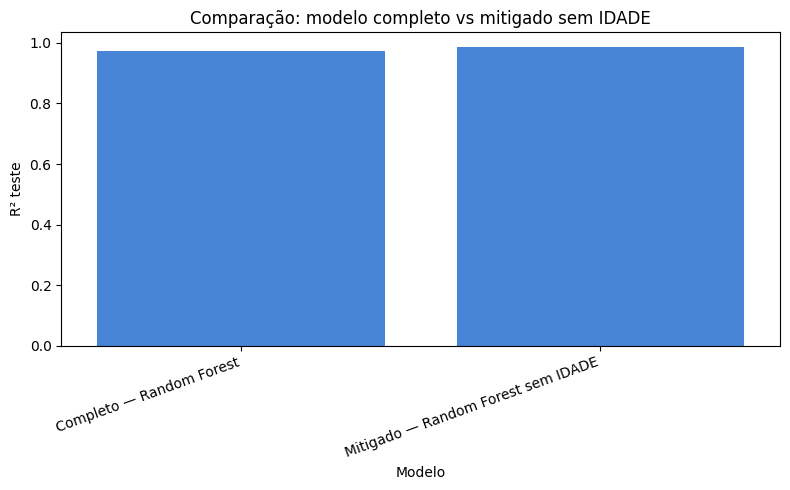

In [ ]:
# ============================================================
# 12. MODELO MITIGADO SEM IDADE
# ============================================================

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mitigado,
    y_final,
    test_size=0.20,
    random_state=42
)

# Usa Random Forest controlado para a comparação mitigada, por ser robusto e interpretável em importância de variáveis.
modelo_mitigado_vies = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=15,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=1
    ))
])

modelo_mitigado_vies.fit(X_train_m, y_train_m)
pred_mitigado = modelo_mitigado_vies.predict(X_test_m)

metricas_completo_vs_mitigado = pd.DataFrame([
    {
        "Modelo": f"Completo — {melhor_modelo_nome}",
        "Features": len(features_modelo_completo),
        "Remove_IDADE": "Não",
        "R2_teste": r2_score(y_test, y_pred_final),
        "MAE_teste": mean_absolute_error(y_test, y_pred_final),
        "RMSE_teste": np.sqrt(mean_squared_error(y_test, y_pred_final))
    },
    {
        "Modelo": "Mitigado — Random Forest sem IDADE",
        "Features": len(features_modelo_mitigado),
        "Remove_IDADE": "Sim",
        "R2_teste": r2_score(y_test_m, pred_mitigado),
        "MAE_teste": mean_absolute_error(y_test_m, pred_mitigado),
        "RMSE_teste": np.sqrt(mean_squared_error(y_test_m, pred_mitigado))
    }
]).round(4)

display(metricas_completo_vs_mitigado)

plt.figure(figsize=(8, 5))
sns.barplot(data=metricas_completo_vs_mitigado, x="Modelo", y="R2_teste", color="#2F80ED")
plt.title("Comparação: modelo completo vs mitigado sem IDADE")
plt.xlabel("Modelo")
plt.ylabel("R² teste")
plt.xticks(rotation=20, ha="right")
plt.show()

Os histogramas apresentam como a idade influenciou no Score, apesar de visualmente próximos, ressaltando a influencia do víes do dataset o resultado final analisado.

## 15. Auditoria de viés por grupos

As variáveis demográficas e socioeconômicas são usadas aqui para **auditoria**, mesmo quando não entram no modelo mitigado. O objetivo é verificar se o erro médio ou a concentração de alto risco previsto muda de forma relevante entre grupos.

,UF,qtd_clientes,erro_medio,score_real_medio,score_previsto_medio,pct_alto_risco_previsto,grupo_auditado,modelo,ESCOLARIDADE,ESTADO_CIVIL,CASA_PROPRIA,OUTRA_RENDA,TRABALHANDO_ATUALMENTE
0,MG,321,2.483178e+00,49.085151,47.325014,59.813084,UF,Completo — Random Forest,NaN,NaN,NaN,NaN,NaN
1,PR,361,2.512151e+00,52.450139,53.249463,47.368421,UF,Completo — Random Forest,NaN,NaN,NaN,NaN,NaN
2,RJ,643,1.988742e+00,53.211768,53.841592,47.589425,UF,Completo — Random Forest,NaN,NaN,NaN,NaN,NaN
3,SC,322,2.313579e+00,49.871636,50.340109,45.341615,UF,Completo — Random Forest,NaN,NaN,NaN,NaN,NaN
4,SP,449,2.127722e+00,51.802524,51.313020,53.006682,UF,Completo — Random Forest,NaN,NaN,NaN,NaN,NaN
5,MG,321,1.065354e+00,49.085151,48.574514,45.171340,UF,Mitigado — Random Forest sem IDADE,NaN,NaN,NaN,NaN,NaN
6,PR,361,1.491759e+00,52.450139,53.234622,41.828255,UF,Mitigado — Random Forest sem IDADE,NaN,NaN,NaN,NaN,NaN
7,RJ,643,1.665371e+00,53.211768,53.422692,44.790047,UF,Mitigado — Random Forest sem IDADE,NaN,NaN,NaN,NaN,NaN
8,SC,322,1.793111e+00,49.871636,50.203360,41.925466,UF,Mitigado — Random Forest sem IDADE,NaN,NaN,NaN,NaN,NaN
9,SP,449,1.712144e+00,51.802524,51.167021,48.106904,UF,Mitigado — Random Forest sem IDADE,NaN,NaN,NaN,NaN,NaN


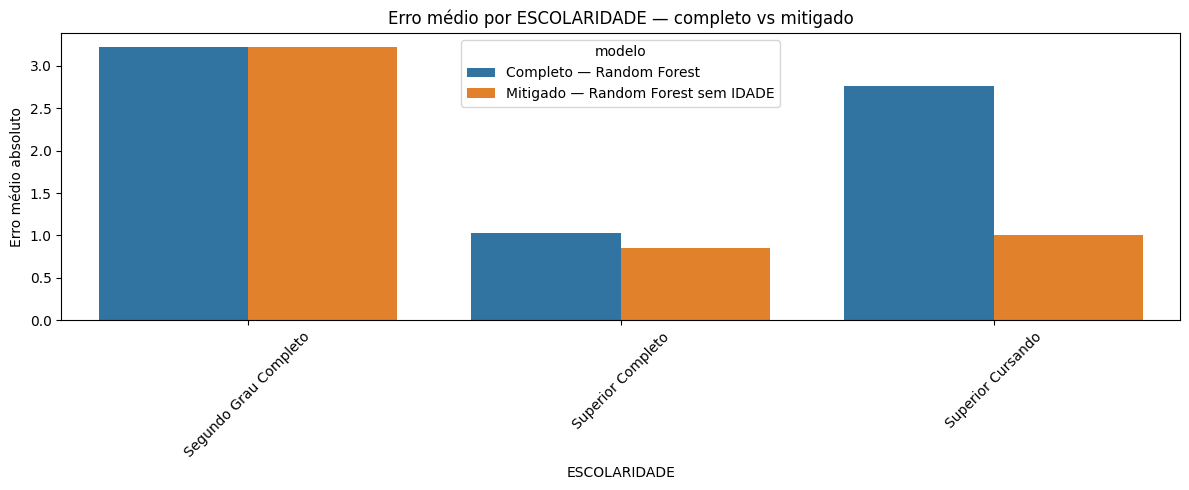

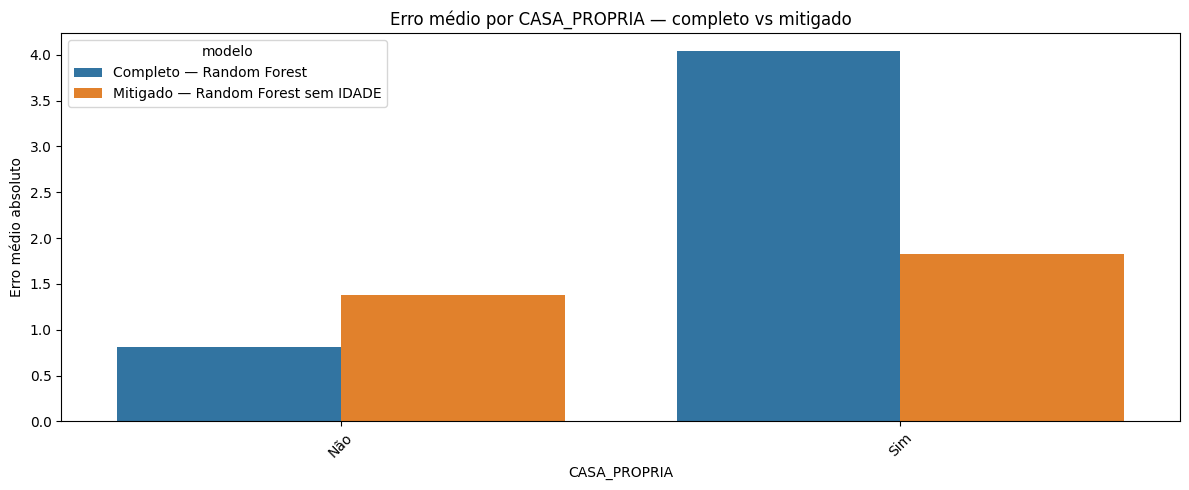

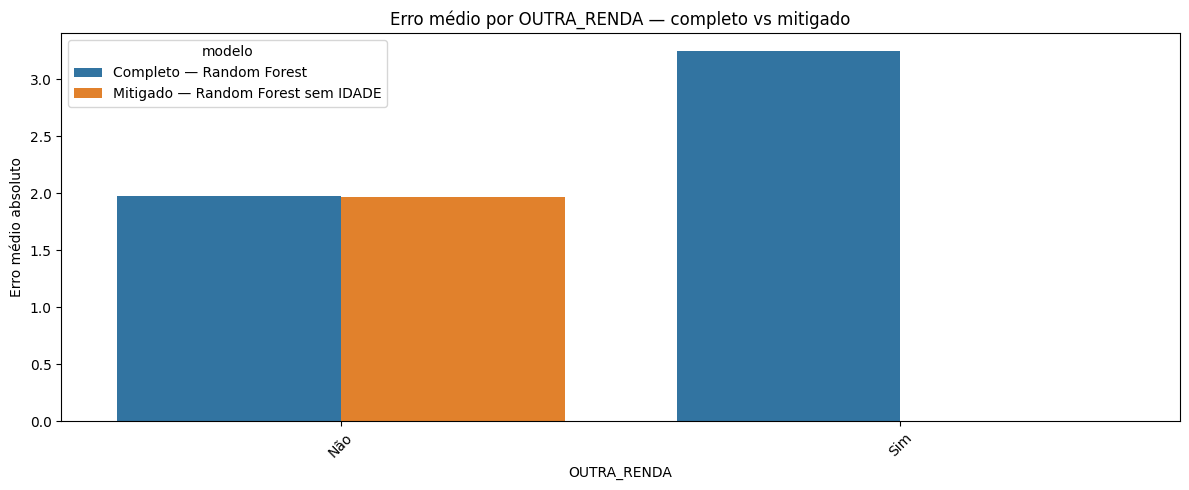

In [ ]:
# ============================================================
# 13. AUDITORIA DE VIÉS POR GRUPOS
# ============================================================

def classificar_risco_score(score):
    if score <= 40:
        return "Alto risco"
    elif score <= 70:
        return "Risco médio"
    else:
        return "Baixo risco"

# Auditoria do modelo completo no conjunto de teste
base_auditoria_completo = df_features.loc[X_test.index].copy()
base_auditoria_completo["SCORE_REAL"] = y_test.values
base_auditoria_completo["SCORE_PREVISTO"] = y_pred_final
base_auditoria_completo["ERRO_ABSOLUTO"] = abs(base_auditoria_completo["SCORE_REAL"] - base_auditoria_completo["SCORE_PREVISTO"])
base_auditoria_completo["FAIXA_RISCO_PREVISTA"] = base_auditoria_completo["SCORE_PREVISTO"].apply(classificar_risco_score)
base_auditoria_completo["MODELO_AUDITADO"] = f"Completo — {melhor_modelo_nome}"

# Auditoria do modelo mitigado no conjunto de teste mitigado
base_auditoria_mitigado = df_features.loc[X_test_m.index].copy()
base_auditoria_mitigado["SCORE_REAL"] = y_test_m.values
base_auditoria_mitigado["SCORE_PREVISTO"] = pred_mitigado
base_auditoria_mitigado["ERRO_ABSOLUTO"] = abs(base_auditoria_mitigado["SCORE_REAL"] - base_auditoria_mitigado["SCORE_PREVISTO"])
base_auditoria_mitigado["FAIXA_RISCO_PREVISTA"] = base_auditoria_mitigado["SCORE_PREVISTO"].apply(classificar_risco_score)
base_auditoria_mitigado["MODELO_AUDITADO"] = "Mitigado — Random Forest sem IDADE"

def auditar_por_grupo(base, grupo, nome_modelo):
    if grupo not in base.columns:
        return pd.DataFrame()
    tab = (
        base
        .groupby(grupo, observed=True)
        .agg(
            qtd_clientes=("ERRO_ABSOLUTO", "size"),
            erro_medio=("ERRO_ABSOLUTO", "mean"),
            score_real_medio=("SCORE_REAL", "mean"),
            score_previsto_medio=("SCORE_PREVISTO", "mean"),
            pct_alto_risco_previsto=("FAIXA_RISCO_PREVISTA", lambda x: (x == "Alto risco").mean() * 100)
        )
        .reset_index()
    )
    tab["grupo_auditado"] = grupo
    tab["modelo"] = nome_modelo
    return tab

grupos_auditoria = ["UF", "FAIXA_IDADE", "ESCOLARIDADE", "ESTADO_CIVIL", "CASA_PROPRIA", "OUTRA_RENDA", "TRABALHANDO_ATUALMENTE"]

auditorias = []
for grupo in grupos_auditoria:
    auditorias.append(auditar_por_grupo(base_auditoria_completo, grupo, f"Completo — {melhor_modelo_nome}"))
    auditorias.append(auditar_por_grupo(base_auditoria_mitigado, grupo, "Mitigado — Random Forest sem IDADE"))

auditoria_vies_modelos = pd.concat([a for a in auditorias if not a.empty], ignore_index=True)

display(auditoria_vies_modelos.head(40))

# Visualização de erro por faixa de idade e escolaridade, se disponíveis
for grupo in ["FAIXA_IDADE", "ESCOLARIDADE", "CASA_PROPRIA", "OUTRA_RENDA"]:
    tab = auditoria_vies_modelos[auditoria_vies_modelos["grupo_auditado"] == grupo].copy()
    if not tab.empty and grupo in tab.columns:
        plt.figure(figsize=(12, 5))
        sns.barplot(data=tab, x=grupo, y="erro_medio", hue="modelo")
        plt.title(f"Erro médio por {grupo} — completo vs mitigado")
        plt.xlabel(grupo)
        plt.ylabel("Erro médio absoluto")
        plt.xticks(rotation=45)
        plt.show()

## 16. Predição de score de novo cliente

Esta função usa o modelo final recomendado pela comparação de métricas. Ela recebe dados de um novo cliente e retorna score previsto, faixa de risco e recomendação.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# 14. PREDIÇÃO DE NOVO CLIENTE
# ============================================================

def recomendar_acao(faixa_risco):
    if faixa_risco == "Alto risco":
        return "Análise manual prioritária e acompanhamento financeiro"
    elif faixa_risco == "Risco médio":
        return "Monitoramento e oferta com exposição controlada"
    else:
        return "Cliente com menor risco: elegível a ofertas ampliadas"

# Definir features_modelo_completo usando a lista 'features' existente
features_modelo_completo = features.copy()

# Definir features_modelo_mitigado (sem 'IDADE')
features_modelo_mitigado = [f for f in features if f != 'IDADE']

# Preparar e treinar o modelo mitigado
X_mitigado = df_features[features_modelo_mitigado].apply(pd.to_numeric, errors='coerce')
y_mitigado = df_features["SCORE"].copy()

X_train_mit, X_test_mit, y_train_mit, y_test_mit = train_test_split(
    X_mitigado, y_mitigado, test_size=0.2, random_state=42
)

imputer_mit = SimpleImputer(strategy='mean')
X_train_mit_imputed = imputer_mit.fit_transform(X_train_mit)
X_test_mit_imputed = imputer_mit.transform(X_test_mit)

scaler_mit = StandardScaler()
X_train_mit_scaled = scaler_mit.fit_transform(X_train_mit_imputed)
X_test_mit_scaled = scaler_mit.transform(X_test_mit_imputed)

modelo_mitigado_vies = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
modelo_mitigado_vies.fit(X_train_mit_scaled, y_train_mit)

def prever_score_cliente(dados_cliente, usar_modelo="completo"):
    """
    usar_modelo='completo' usa o melhor modelo de métrica.
    usar_modelo='mitigado' usa o modelo sem IDADE.
    """
    cliente = pd.DataFrame([dados_cliente])

    if usar_modelo == "mitigado":
        feats = features_modelo_mitigado
        # Escalonar o cliente de exemplo usando o scaler treinado para o modelo mitigado
        modelo = modelo_mitigado_vies
        scaler_to_use = scaler_mit
        imputer_to_use = imputer_mit
    else:
        feats = features_modelo_completo
        modelo = modelo_final
        # Escalonar o cliente de exemplo usando o scaler treinado para o modelo completo
        # X_train_scaled e scaler_final são do modelo completo
        scaler_to_use = scaler_final # Assuming scaler_final from hQEjSj37-WBo is the correct one for the 'completo' model
        imputer_to_use = imputer_final # Assuming imputer_final from hQEjSj37-WBo is the correct one for the 'completo' model

    for col in feats:
        if col not in cliente.columns:
            cliente[col] = np.nan

    cliente_numeric = cliente[feats].copy().apply(pd.to_numeric, errors="coerce")
    cliente_imputed = imputer_to_use.transform(cliente_numeric)
    cliente_scaled = scaler_to_use.transform(cliente_imputed)

    score_previsto = float(modelo.predict(cliente_scaled)[0])
    faixa = classificar_risco_score(score_previsto)
    recomendacao = recomendar_acao(faixa)

    return {
        "score_previsto": round(score_previsto, 2),
        "faixa_risco_prevista": faixa,
        "recomendacao": recomendacao,
        "modelo_utilizado": usar_modelo
    }

cliente_exemplo = {
    "IDADE": 35,
    "QT_FILHOS": 1,
    "QT_IMOVEIS": 0,
    "VL_IMOVEIS": 0,
    "OUTRA_RENDA_VALOR": 0,
    "TEMPO_ULTIMO_EMPREGO_MESES": 24,
    "ULTIMO_SALARIO": 3500,
    "QT_CARROS": 1,
    "VALOR_TABELA_CARROS": 30000
}

print("Predição com modelo completo:")
display(prever_score_cliente(cliente_exemplo, usar_modelo="completo"))

print("Predição com modelo mitigado:")
display(prever_score_cliente(cliente_exemplo, usar_modelo="mitigado"))

Predição com modelo completo:


{'score_previsto': 33.62,
 'faixa_risco_prevista': 'Alto risco',
 'recomendacao': 'Análise manual prioritária e acompanhamento financeiro',
 'modelo_utilizado': 'completo'}

Predição com modelo mitigado:


{'score_previsto': 33.62,
 'faixa_risco_prevista': 'Alto risco',
 'recomendacao': 'Análise manual prioritária e acompanhamento financeiro',
 'modelo_utilizado': 'mitigado'}

In [ ]:
# ============================================================
# RELATÓRIO POWER BI EM HTML
# ============================================================

import os
import zipfile
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# Função para gerar HTML interativo dos gráficos
def fig_to_html(fig):
    if fig is None:
        return "<p>Gráfico não disponível.</p>"
    return fig.to_html(full_html=False, include_plotlyjs=False)

def format_num(x, casas=2):
    if pd.isna(x):
        return "-"
    return f"{x:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# ============================================================
# 1. VERIFICAÇÃO E CARREGAMENTO DAS BASES
# ============================================================

# Verifique se df_comparativo_final foi gerado corretamente
if "df_comparativo_final" not in globals() or df_comparativo_final.empty:
    raise ValueError("df_comparativo_final não foi encontrado ou está vazio. Execute a etapa de modelagem corretamente.")

# Exibindo a tabela de comparações
print("--- TABELA COMPARATIVA DE MODELOS (FINAL) ---")
display(df_comparativo_final)

# ============================================================
# 2. GRÁFICOS PRINCIPAIS (R², MAE, RMSE)
# ============================================================

# Comparação entre R² de cada modelo
fig_r2_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="R²",
    title="Comparação de R² entre os Modelos",
    color="R²",
    labels={"R²": "Coeficiente de Determinação (R²)", "Modelo": "Modelo"}
)

# Comparação de MAE entre os modelos
fig_mae_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="MAE",
    title="Comparação de MAE entre os Modelos",
    color="MAE",
    labels={"MAE": "Erro Absoluto Médio (MAE)", "Modelo": "Modelo"}
)

# Comparação de RMSE entre os modelos
fig_rmse_comparativo = px.bar(
    df_comparativo_final,
    x="Modelo",  # Corrigido para "Modelo" (com M maiúsculo)
    y="RMSE",
    title="Comparação de RMSE entre os Modelos",
    color="RMSE",
    labels={"RMSE": "Raiz do Erro Quadrático Médio (RMSE)", "Modelo": "Modelo"}
)

# ============================================================
# 3. CRIAÇÃO DOS CARDS E EXIBIÇÃO DOS RESULTADOS
# ============================================================

# Gerando o conteúdo HTML do relatório
html = f"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="UTF-8">
<title>Relatório Comparativo de Modelos - Grupo 20</title>
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
<style>
    body {{
        font-family: Arial, Helvetica, sans-serif;
        margin: 0;
        background-color: #F9FAFB;
    }}
    .container {{
        max-width: 1200px;
        margin: auto;
        background-color: white;
        padding: 20px;
        border-radius: 10px;
        box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1);
    }}
    h1 {{
        color: #333;
        text-align: center;
    }}
    .card {{
        background-color: #fff;
        border: 1px solid #ddd;
        padding: 15px;
        border-radius: 8px;
        margin-bottom: 20px;
    }}
    .card-title {{
        font-size: 18px;
        font-weight: bold;
        margin-bottom: 10px;
    }}
    .tabela {{
        width: 100%;
        border-collapse: collapse;
        margin-top: 15px;
    }}
    .tabela th {{
        background: #2563EB;
        color: white;
        padding: 9px;
        text-align: left;
    }}
    .tabela td {{
        padding: 8px;
        border-bottom: 1px solid #E5E7EB;
    }}
</style>
</head>
<body>

<div class="container">
    <h1>Relatório Comparativo de Modelos - Score de Crédito</h1>

    <div class="card">
        <div class="card-title">Comparação de R² entre os Modelos</div>
        {fig_to_html(fig_r2_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de MAE entre os Modelos</div>
        {fig_to_html(fig_mae_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Comparação de RMSE entre os Modelos</div>
        {fig_to_html(fig_rmse_comparativo)}
    </div>

    <div class="card">
        <div class="card-title">Tabela Comparativa Final</div>
        <table class="tabela">
            <thead>
                <tr>
                    <th>Modelo</th>
                    <th>R²</th>
                    <th>MAE</th>
                    <th>RMSE</th>
                </tr>
            </thead>
            <tbody>
                {df_comparativo_final.to_html(index=False, header=False, escape=False)}
            </tbody>
        </table>
    </div>

</div>

</body>
</html>
"""

# Salvar o arquivo HTML
html_filename = "/mnt/data/relatorio_comparativo_modelos_grupo20.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(html)

print(f"✅ Relatório HTML gerado com sucesso: {html_filename}")

# ============================================================
# 4. CRIAR ARQUIVO ZIP
# ============================================================

# Criando o arquivo ZIP para exportação
zip_name = "/mnt/data/entregaveis_grupo20_comparativo_modelos.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    zipf.write(html_filename)

print(f"✅ Arquivo ZIP criado com sucesso: {zip_name}")

# Para baixar no Colab, descomente:
from google.colab import files
files.download(html_filename)
files.download(zip_name)

--- TABELA COMPARATIVA DE MODELOS (FINAL) ---


,Modelo,R²,MAE,RMSE
2,Random Forest,0.9736,2.2343,4.4746
0,Linear Regression,0.7157,11.0753,14.6776
1,Ridge Regression,0.7157,11.0762,14.6775


✅ Relatório HTML gerado com sucesso: /mnt/data/relatorio_comparativo_modelos_grupo20.html
✅ Arquivo ZIP criado com sucesso: /mnt/data/entregaveis_grupo20_comparativo_modelos.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Conclusão final para a entrega

A versão final integra a pipeline de SQLite, EDA, modelagem e viés. A modelagem revisada foi mantida como base principal porque apresentou melhores métricas.


A seguir, um breve resumo teórico sobre os modelos utilizados e uma explicação dos motivos da superioridade do modelo RandomForest na nossa análise:

**Linear Regression (Regressão Linear):**

- Atua como o nosso baseline (modelo de referência), buscando uma relação linear direta entre as variáveis e o score.

- Embora seja altamente interpretável, pode ter dificuldade em capturar padrões complexos e não lineares presentes nos dados de crédito.

**Ridge Regression:**

- Uma evolução da regressão linear que utiliza regularização L2 para lidar com a alta multicolinearidade que identificamos no heatmap (correlações de até 0,97).

- Ela penaliza coeficientes excessivamente grandes, tornando as previsões mais estáveis e evitando que o modelo fique "viciado" em variáveis redundantes.

**Random Forest Regressor:**

- Um modelo de Ensemble baseado em múltiplas árvores de decisão que trabalham em conjunto para reduzir o erro e o overfitting.

- **Por que foi superior?** Diferente dos modelos lineares, o Random Forest consegue capturar interações complexas entre as variáveis (como a relação mútua entre tempo de emprego, salário e patrimônio). **Ele se mostrou mais robusto aos outliers identificados nos nossos boxplots e entregou o melhor R², provando ser o modelo com maior poder explicativo para este dataset.**


O modelo final é escolhido automaticamente pela tabela comparativa, mas sua interpretação é acompanhada por validação cruzada, teste com `SCORE` embaralhado e auditoria de viés.

A questão de viés foi incorporada de três formas:

1. análise do score e do alto risco por grupos;
2. comparação entre modelo completo e modelo mitigado sem `IDADE`;
3. auditoria de erro por subgrupos.

Assim, a solução não depende apenas da métrica do modelo. Ela também considera qualidade dos dados, possíveis proxies socioeconômicas, rastreabilidade via SQLite e exportação para visualização executiva.


